In [1]:
import pandas as pd
from pycaret.classification import *
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

from imblearn.combine import SMOTEENN
import optunahub
import optuna

from pycaret.internal.preprocess.transformers import TransformerWrapper

# Innits


In [2]:
gw=35
data_22_23 = pd.read_csv('./data/joint/22-23/merged_player_data.csv',).dropna()
data_23_24 = pd.read_csv('./data/joint/23-24/merged_player_data.csv').dropna()
data_24_25 = pd.read_csv('./data/joint/24-25/merged_player_data.csv')

data_tar = data_24_25[data_24_25['event']==gw]
data_24_25_ = data_24_25[data_24_25['event'] < gw]
data_24_25_test = data_24_25[data_24_25['event'] > gw]

data = pd.concat([data_22_23, data_23_24, data_24_25_])


data_36 = data_24_25_test[data_24_25_test['event'] == 36]
data_37 = data_24_25_test[data_24_25_test['event'] == 37]
data_38 = data_24_25_test[data_24_25_test['event'] == 38]

data_36_gk = data_36[data_36['position'] == 'GK']
data_37_gk = data_37[data_37['position'] == 'GK']
data_38_gk = data_38[data_38['position'] == 'GK']

data_36_def = data_36[data_36['position'] == 'DEF']
data_37_def = data_37[data_37['position'] == 'DEF']
data_38_def = data_38[data_38['position'] == 'DEF']


data_36_mid = data_36[data_36['position'] == 'MID']
data_37_mid = data_37[data_37['position'] == 'MID']
data_38_mid = data_38[data_38['position'] == 'MID']


data_36_fwd = data_36[data_36['position'] == 'FWD']
data_37_fwd = data_37[data_37['position'] == 'FWD']
data_38_fwd = data_38[data_38['position'] == 'FWD']

In [3]:
data_36_gk

,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,npxG_5,xGChain_5,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha
45,0,3,31,1,0.0,14,0.00,0.00,0.0,1.82,...,0.0,0.12,0.12,2.40,-4915.0,-0.457838,7.0,0.086,0.126,0.788
463,0,0,9,0,0.0,310,0.00,0.00,0.0,2.31,...,0.0,0.30,0.30,2.62,-18038.0,-0.597525,2.0,0.474,0.263,0.263
490,0,1,30,1,0.0,513,0.00,0.00,0.0,2.28,...,0.0,0.21,0.21,1.40,-3310.0,-0.063593,7.0,0.499,0.264,0.237
979,0,1,28,1,0.0,146,0.00,0.00,0.0,0.91,...,0.0,0.14,0.14,0.64,-6751.0,-0.456744,7.0,0.351,0.271,0.379
1141,0,0,3,0,0.0,248,0.00,0.00,0.0,1.12,...,0.0,0.16,0.16,1.62,3105.0,-0.037582,2.0,0.516,0.276,0.209
2457,0,0,7,0,0.0,15,0.00,0.00,0.0,2.56,...,0.0,0.21,0.21,4.54,-134753.0,-0.871236,2.0,0.474,0.263,0.263
2495,0,0,23,1,0.0,201,0.00,0.00,0.0,0.68,...,0.0,0.09,0.09,2.34,-29255.0,-0.570065,6.0,0.359,0.263,0.378
2913,0,0,19,1,0.0,347,0.00,0.00,0.0,0.10,...,0.0,0.30,0.21,3.50,77126.0,0.868847,6.0,0.086,0.126,0.788
3076,0,2,28,1,0.0,47,0.01,0.01,0.0,0.80,...,0.0,0.30,0.24,3.88,13072.0,0.263253,6.0,0.394,0.263,0.344
4504,0,0,5,0,0.0,304,0.00,0.00,0.0,1.31,...,0.0,0.18,0.18,1.08,2184.0,0.243365,1.0,0.704,0.178,0.117


In [4]:
features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'ownership_change', 'percenatge_net_transfers',

            'clean_sheets', 'expected_assists', 'expected_goal_involvements', 'expected_goals', 'expected_goals_conceded', 'goals_conceded', 'goals_scored', 'ict_index',
            'influence', 'creativity', 'threat', 'minutes', 'own_goals', 'penalties_missed', 'penalties_saved', 'red_cards', 'yellow_cards', 'saves', 'starts',
            'team_a_score', 'team_h_score', 'total_points', 'goals', 'shots', 'xG', 'xA', 'assists_x', 'assists_y', 'key_passes', 'npg', 'npxG', 'xGChain',  'xGBuildup',  'xP',

            'clean_sheets_1', 'expected_assists_1', 'expected_goal_involvements_1', 'expected_goals_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_missed_1', 'penalties_saved_1', 'red_cards_1', 'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'goals_1', 'shots_1', 'xG_1', 'xA_1', 'assists_x_1', 'assists_y_1', 'key_passes_1', 'npg_1', 'npxG_1', 'xGChain_1',
            'xGBuildup_1',  'xP_1',

            'clean_sheets_2', 'expected_assists_2', 'expected_goal_involvements_2', 'expected_goals_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'goals_scored_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_missed_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'goals_2', 'shots_2', 'xG_2', 'xA_2', 'assists_x_2', 'assists_y_2', 'key_passes_2', 'npg_2', 'npxG_2', 'xGChain_2',
            'xGBuildup_2',  'xP_2',

            'clean_sheets_3', 'expected_assists_3', 'expected_goal_involvements_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'goals_scored_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_missed_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'goals_3', 'shots_3', 'xG_3', 'xA_3', 'assists_x_3', 'assists_y_3', 'key_passes_3', 'npg_3', 'npxG_3', 'xGChain_3',
            'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_assists_4', 'expected_goal_involvements_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'goals_scored_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_missed_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'goals_4', 'shots_4', 'xG_4', 'xA_4', 'assists_x_4', 'assists_y_4', 'key_passes_4', 'npg_4', 'npxG_4', 'xGChain_4',
            'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_assists_5', 'expected_goal_involvements_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'goals_scored_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_missed_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5', 'goals_5', 'shots_5', 'xG_5', 'xA_5', 'assists_x_5', 'assists_y_5', 'key_passes_5', 'npg_5', 'npxG_5', 'xGChain_5',
            'xGBuildup_5',  'xP_5'
                        ]

# Clean Sheets


## GK


### Base Model


In [5]:
g_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty',  'ownership_change', 'percenatge_net_transfers',
            'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4',  'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5',  'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

g_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_cs_data = g_cs_data[g_cs_features]
g_cs_data_tar = g_cs_data_tar[g_cs_features]

g_cs_data.reset_index(drop=True, inplace=True)
g_cs_data.reset_index(drop=True, inplace=True)

g_cs_data.drop(columns=['position'], inplace=True)
g_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)

clean_sheets
0    1231
1     381
Name: count, dtype: int64


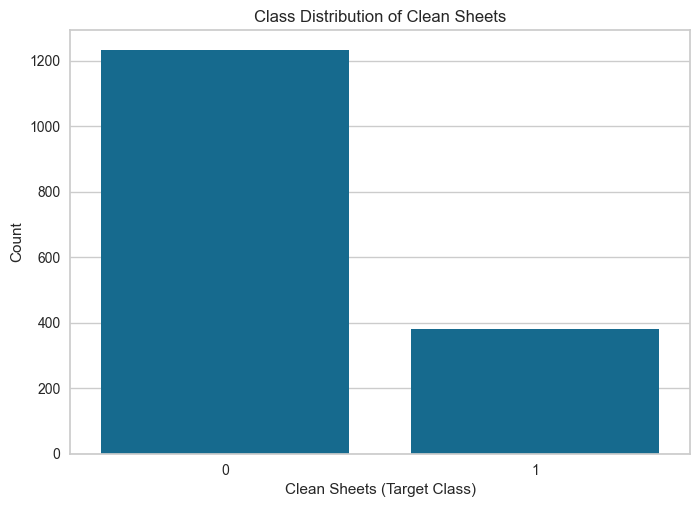

In [6]:
print(g_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=g_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

In [8]:
base_g_cs_model = setup(g_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=False,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    # remove_multicollinearity=False,  # Drop collinear features
                    feature_selection=False,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=False
                )

base_g_cs_best = base_g_cs_model.compare_models(sort='AUC')
base_g_cs_best

,Description,Value
0,Session id,5732
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(1612, 113)"
4,Transformed data shape,"(1612, 113)"
5,Transformed train set shape,"(1289, 113)"
6,Transformed test set shape,"(323, 113)"
7,Numeric features,111
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.7564,0.6034,0.0196,0.2786,0.0353,0.0065,0.0201,2.1090
ridge,Ridge Classifier,0.7502,0.5969,0.0359,0.3117,0.0636,0.0110,0.0244,0.0890
nb,Naive Bayes,0.5485,0.5873,0.5837,0.2836,0.3805,0.0904,0.1041,0.0720
lda,Linear Discriminant Analysis,0.7347,0.5788,0.1049,0.3378,0.1564,0.0459,0.0604,0.0550
lightgbm,Light Gradient Boosting Machine,0.7525,0.5761,0.1082,0.4344,0.1699,0.0810,0.1104,0.6880
gbc,Gradient Boosting Classifier,0.7564,0.5744,0.0824,0.4189,0.1352,0.0652,0.0941,0.7870
et,Extra Trees Classifier,0.7564,0.5594,0.0195,0.3583,0.0364,0.0063,0.0231,0.2590
xgboost,Extreme Gradient Boosting,0.7456,0.5480,0.1151,0.3730,0.1734,0.0727,0.0902,0.4260
rf,Random Forest Classifier,0.7611,0.5466,0.0197,0.3750,0.0370,0.0156,0.0380,0.5570
dt,Decision Tree Classifier,0.6540,0.5318,0.3004,0.2780,0.2880,0.0602,0.0606,0.1490


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=5732, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [9]:
evaluate_model(base_g_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

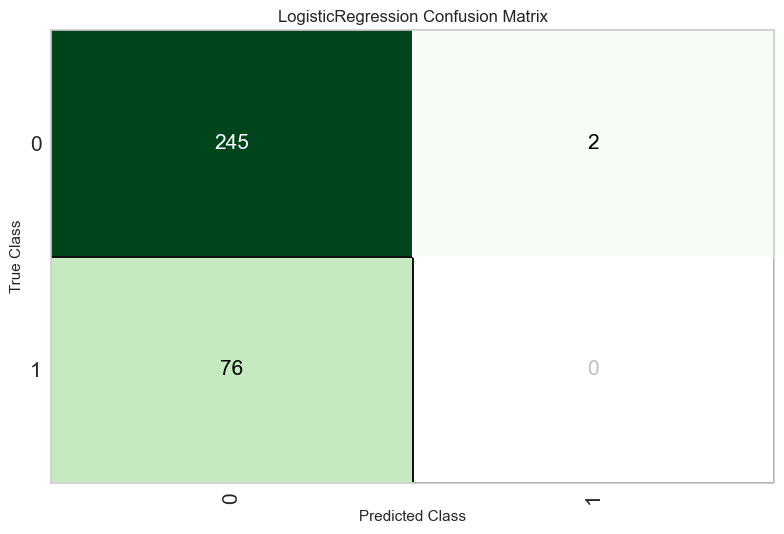

In [10]:
plot_model(base_g_cs_best, plot='confusion_matrix')

### Tuned Model


In [31]:
# Enhanced setup for better performance
tuned_g_cs_model = setup(g_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

g_cs_best = tuned_g_cs_model.compare_models(n_select=3, sort='F1')
g_cs_best

NameError: name 'g_cs_data' is not defined

In [234]:
# Ensemble (blend or stack)
g_cs_blended = blend_models(g_cs_best, optimize='F1')

,,
,,
Initiated,. . . . . . . . . . . . . . . . . .,16:44:44
Status,. . . . . . . . . . . . . . . . . .,Fitting 10 Folds
Estimator,. . . . . . . . . . . . . . . . . .,Voting Classifier


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5426,0.6077,0.5667,0.2698,0.3656,0.0737,0.0862
1,0.5349,0.4872,0.4333,0.2321,0.3023,-0.0008,-0.0009
2,0.6589,0.6832,0.5333,0.3478,0.4211,0.1942,0.2031
3,0.5426,0.5172,0.6000,0.2769,0.3789,0.0890,0.1058
4,0.4496,0.3137,0.2581,0.1429,0.1839,-0.1817,-0.1998
5,0.5039,0.5194,0.4194,0.2203,0.2889,-0.0382,-0.0429
6,0.5426,0.5458,0.5484,0.2742,0.3656,0.0665,0.0763
7,0.5814,0.6274,0.6129,0.3115,0.4130,0.1385,0.1578
8,0.5736,0.5767,0.4516,0.2692,0.3373,0.0519,0.0556


In [235]:
g_cs_tuned = tune_model(g_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5891,0.6303,0.6000,0.3051,0.4045,0.1390,0.1576
1,0.5814,0.5128,0.4333,0.2600,0.3250,0.0484,0.0517
2,0.6589,0.6798,0.5333,0.3478,0.4211,0.1942,0.2031
3,0.5736,0.5364,0.5000,0.2727,0.3529,0.0744,0.0820
4,0.4729,0.4055,0.1935,0.1224,0.1500,-0.2046,-0.2159
5,0.5349,0.5115,0.3871,0.2264,0.2857,-0.0252,-0.0272
6,0.5039,0.4822,0.4516,0.2295,0.3043,-0.0210,-0.0239
7,0.6279,0.5885,0.5484,0.3333,0.4146,0.1650,0.1760
8,0.5891,0.5527,0.4194,0.2708,0.3291,0.0524,0.0550


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


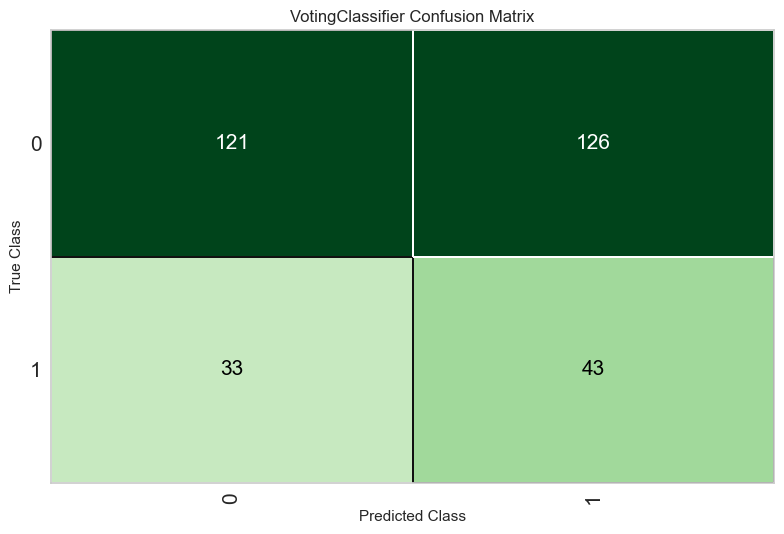

In [236]:
plot_model(g_cs_tuned, plot='confusion_matrix')

In [237]:
# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(g_cs_tuned, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.5077,0.5438,0.5658,0.2544,0.3510,0.0391,0.0473


In [238]:
evaluate_model(g_cs_tuned)


interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [42]:

# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols


In [11]:
g_cs_final_model = finalize_model(base_g_cs_best)

In [53]:
# import joblib
# # Save the features the model expects
# first_step = list(g_cs_final_model.named_steps.keys())[0]
# expected_features = list(g_cs_final_model.named_steps[first_step].feature_names_in_)
# joblib.dump(expected_features, './models/g_cs_features.pkl')

save_model(g_cs_final_model, './models/g_cs_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                importance_type=None,
                                interaction_cons

### Predictions


In [242]:
data_36_gk_cs = data_36_gk[g_cs_features]
data_37_gk_cs = data_37_gk[g_cs_features]
data_38_gk_cs = data_38_gk[g_cs_features]
# Load model
g_cs_model = load_model('./models/g_cs_final_model')

Transformation Pipeline and Model Successfully Loaded


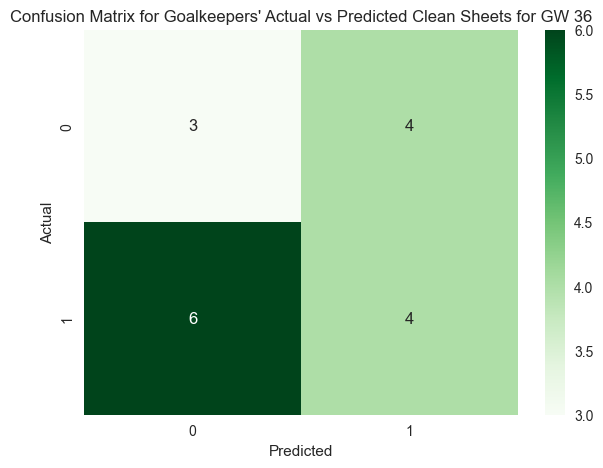

In [244]:
# data_36_gk.reset_index(drop=True, inplace=True)
g_cs = data_36_gk[['clean_sheets']].copy()
data_36_gk.drop(columns=['position', 'clean_sheets'], inplace=True)

g_cs_preds_36 = predict_model(g_cs_model, data=data_36_gk)
g_cs_preds_36 = g_cs_preds_36.rename(columns={'prediction_label': 'cs_preds'})

# Add predicted to data_36_def
data_36_def['cs_preds'] = g_cs_preds_36['cs_preds']

# Generate a confusion matrix
cm = confusion_matrix(g_cs_preds_36['cs_preds'], g_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Goalkeepers' Actual vs Predicted Clean Sheets for GW 36")
plt.show()


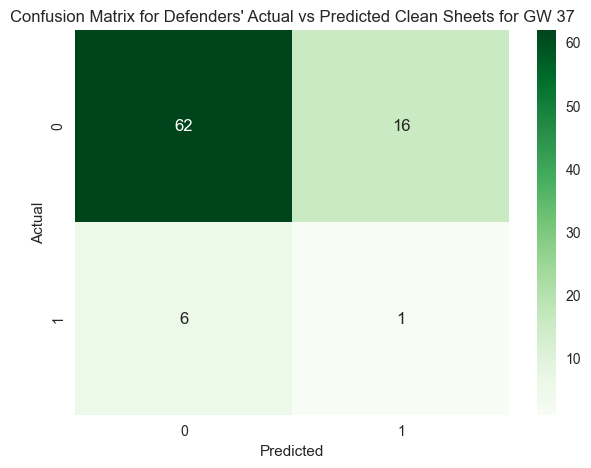

In [245]:

# data_37_def_cs.reset_index(drop=True, inplace=True)
d_cs = data_37_def_cs[['clean_sheets']].copy()
data_37_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

d_cs_preds_37 = predict_model(d_cs_model, data=data_37_def_cs)
d_cs_preds_37 = d_cs_preds_37.rename(columns={'prediction_label': 'cs_preds'})

# Add predicted to data_37_def
data_37_def['cs_preds'] = d_cs_preds_37['cs_preds']

# Generate a confusion matrix
cm = confusion_matrix(d_cs_preds_37['cs_preds'], d_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Defenders' Actual vs Predicted Clean Sheets for GW 37")
plt.show()


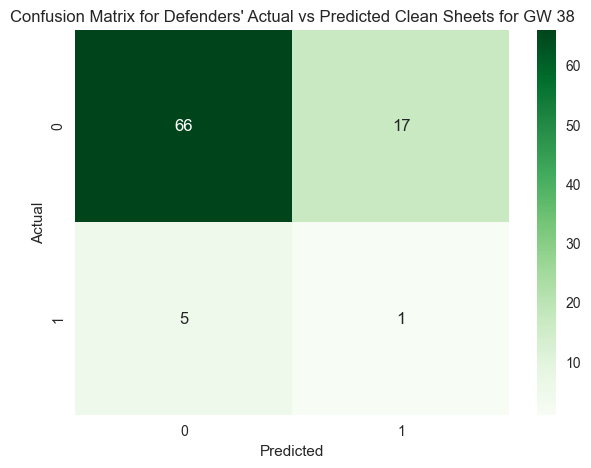

In [246]:
# data_38_def_cs.reset_index(drop=True, inplace=True)
d_cs = data_38_def_cs[['clean_sheets']].copy()
data_38_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

d_cs_preds_38 = predict_model(d_cs_model, data=data_38_def_cs)
d_cs_preds_38 = d_cs_preds_38.rename(columns={'prediction_label': 'cs_preds'})

# Add predicted to data_38_def
data_38_def['cs_preds'] = d_cs_preds_38['cs_preds']

# Generate a confusion matrix
cm = confusion_matrix(d_cs_preds_38['cs_preds'], d_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Defenders' Actual vs Predicted Clean Sheets for GW 38")
plt.show()

## Def


In [21]:
d_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                 'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



def_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_cs_data = def_cs_data[d_cs_features]
def_cs_data_tar = def_cs_data_tar[d_cs_features]

def_cs_data.reset_index(drop=True, inplace=True)
def_cs_data.reset_index(drop=True, inplace=True)

def_cs_data.drop(columns=['position'], inplace=True)
def_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)


clean_sheets
0    5131
1    1442
Name: count, dtype: int64


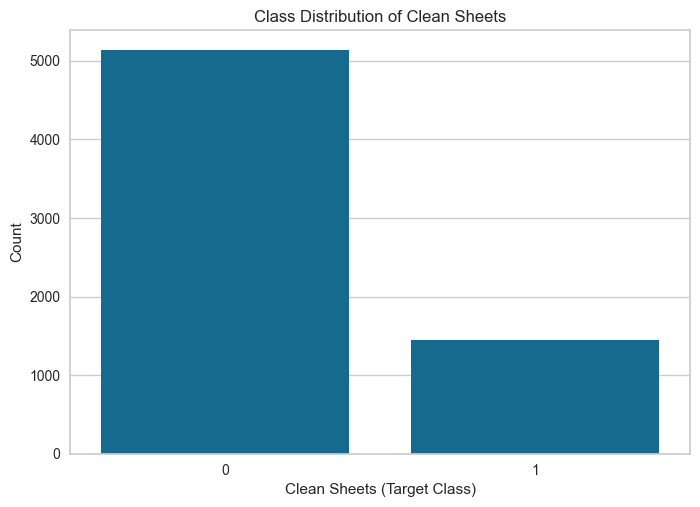

In [21]:
print(def_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=def_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base Model


In [25]:
def_cs_data.shape

(6573, 113)

In [22]:
base_def_cs_model = setup(def_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_def_cs_best = base_def_cs_model.compare_models(sort='AUC')
base_def_cs_best

[LightGBM] [Info] Number of positive: 4104, number of negative: 4104
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.106012 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 16708
[LightGBM] [Info] Number of data points in the train set: 8208, number of used features: 76
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,653
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(9523, 24)"
5,Transformed train set shape,"(8208, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,114
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8539,0.8561,0.4809,0.7659,0.5894,0.5065,0.5275,2.1590
rf,Random Forest Classifier,0.8410,0.8443,0.3431,0.8362,0.4857,0.4108,0.4683,3.0020
xgboost,Extreme Gradient Boosting,0.8311,0.8048,0.3736,0.7261,0.4916,0.4029,0.4357,2.0070
lightgbm,Light Gradient Boosting Machine,0.8155,0.7900,0.2514,0.7349,0.3729,0.2945,0.3535,7.0950
knn,K Neighbors Classifier,0.5873,0.7145,0.7590,0.3165,0.4466,0.1983,0.2474,2.4900
gbc,Gradient Boosting Classifier,0.7817,0.6719,0.0434,0.5109,0.0795,0.0484,0.0976,4.2710
lda,Linear Discriminant Analysis,0.5968,0.6262,0.5694,0.2881,0.3824,0.1285,0.1453,1.7260
dt,Decision Tree Classifier,0.7332,0.6248,0.4317,0.3994,0.4138,0.2417,0.2427,2.7120
ridge,Ridge Classifier,0.5970,0.6229,0.5650,0.2872,0.3807,0.1267,0.1429,1.7590
lr,Logistic Regression,0.5989,0.6220,0.5624,0.2880,0.3807,0.1277,0.1436,2.7610


ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=653, verbose=0,
                     warm_start=False)

In [23]:
evaluate_model(base_def_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [24]:
# pcc.plot_model(tuned, plot='threshold')
predict_model(base_def_cs_best, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8791,0.9041,0.5451,0.8486,0.6638,0.5944,0.6160


,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,ownership_change,percenatge_net_transfers,ict_index,influence,...,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,clean_sheets,prediction_label,prediction_score_0,prediction_score_1
1783,0.248,0.236,0.516,True,5,3,-3416.0,-0.485138,0.0,0.000000,...,1.2,1.2,2.6,0.15,0.11,1.70,1,1,0.16,0.84
695,0.402,0.266,0.332,True,3,4,3226.0,0.524587,2.5,12.200000,...,0.6,1.8,2.8,0.37,0.37,1.20,1,0,0.57,0.43
1996,0.551,0.249,0.200,False,2,3,-1233.0,-0.613538,2.6,25.000000,...,2.0,1.8,1.0,0.25,0.25,1.26,0,0,0.91,0.09
1067,0.218,0.225,0.556,False,3,2,83017.0,0.482244,8.1,25.799999,...,1.6,2.6,1.6,0.67,0.61,3.48,0,0,0.71,0.29
3498,0.146,0.158,0.696,False,5,4,0.0,0.926235,2.5,16.000000,...,2.4,2.0,12.0,0.81,0.57,11.20,1,1,0.19,0.81
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4007,0.361,0.288,0.352,False,2,2,365.0,0.143727,0.4,2.800000,...,1.2,1.6,2.4,0.37,0.36,1.74,0,0,0.81,0.19
5337,0.212,0.238,0.550,False,5,3,814.0,0.027302,2.3,22.200001,...,1.4,2.2,2.0,0.49,0.48,2.10,0,0,0.71,0.29
1059,0.395,0.279,0.327,True,3,4,13821.0,0.450378,10.8,40.200001,...,1.2,1.2,2.2,0.34,0.32,2.70,1,1,0.42,0.58
324,0.330,0.297,0.373,True,2,2,451.0,0.432056,6.5,27.200001,...,2.2,1.2,1.4,0.08,0.05,0.30,0,0,0.72,0.28


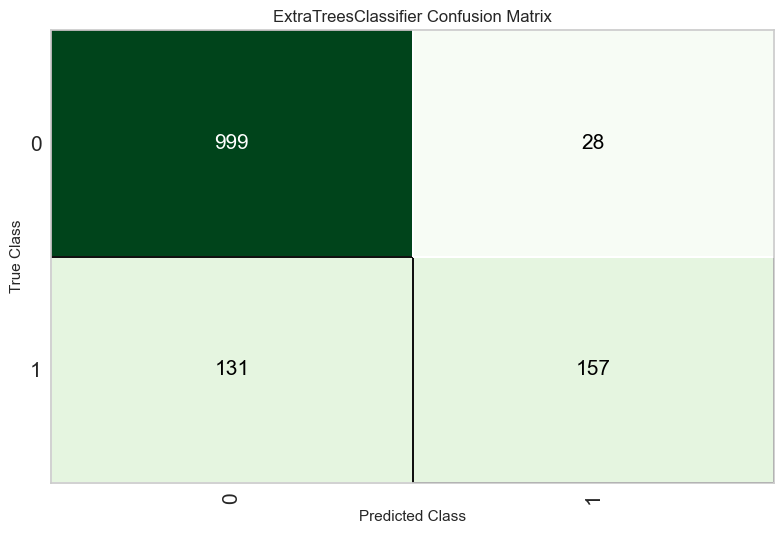

In [25]:
plot_model(base_def_cs_best, plot='confusion_matrix')

In [26]:
base_def_cs_tuned = tune_model(base_def_cs_best, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7300,0.7028,0.3739,0.3805,0.3772,0.2049,0.2049
1,0.7072,0.6783,0.4522,0.3636,0.4031,0.2122,0.2144
2,0.7167,0.7028,0.4348,0.3731,0.4016,0.2175,0.2186
3,0.7662,0.7443,0.3826,0.4583,0.4171,0.2723,0.2740
4,0.6996,0.6654,0.3966,0.3433,0.3680,0.1723,0.1731
5,0.7300,0.7020,0.4397,0.3984,0.4180,0.2428,0.2433
6,0.7414,0.6976,0.3190,0.3936,0.3524,0.1931,0.1947
7,0.7548,0.7251,0.3534,0.4316,0.3886,0.2371,0.2390
8,0.7429,0.7142,0.4000,0.4107,0.4053,0.2413,0.2413


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Tuned Model


In [28]:
# Enhanced setup for better performance

def _reorder_cols(self, df, original_df):
    return df  # Disable column reordering to avoid IndexError

TransformerWrapper._reorder_cols = _reorder_cols

tuned_def_cs_model = setup(def_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

def_cs_best = tuned_def_cs_model.compare_models(n_select=3, sort='F1')
def_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(4543, 65)"
5,Transformed train set shape,"(3228, 65)"
6,Transformed test set shape,"(1315, 65)"
7,Numeric features,114
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7100,0.7012,0.5137,0.3798,0.4362,0.2468,0.2524,1.1530
xgboost,Extreme Gradient Boosting,0.7223,0.6907,0.4203,0.3813,0.3988,0.2192,0.2202,1.1780
lr,Logistic Regression,0.5221,0.6306,0.7192,0.2747,0.3974,0.1172,0.1559,0.8750
lightgbm,Light Gradient Boosting Machine,0.7221,0.6982,0.4142,0.3776,0.3944,0.2148,0.2155,1.8360
ridge,Ridge Classifier,0.5186,0.6239,0.7044,0.2704,0.3906,0.1080,0.1433,0.8570
lda,Linear Discriminant Analysis,0.5221,0.6243,0.6983,0.2708,0.3900,0.1084,0.1432,0.6880
knn,K Neighbors Classifier,0.4184,0.5968,0.8145,0.2485,0.3807,0.0669,0.1123,0.7670
rf,Random Forest Classifier,0.7063,0.6785,0.3985,0.3517,0.3719,0.1820,0.1835,1.4490
dt,Decision Tree Classifier,0.6350,0.5784,0.4774,0.2958,0.3648,0.1287,0.1359,0.8140
svm,SVM - Linear Kernel,0.4842,0.5764,0.6664,0.2489,0.3619,0.0624,0.0841,0.7640


[ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                      criterion='gini', max_depth=None, max_features='sqrt',
                      max_leaf_nodes=None, max_samples=None,
                      min_impurity_decrease=0.0, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      monotonic_cst=None, n_estimators=100, n_jobs=-1,
                      oob_score=False, random_state=123, verbose=0,
                      warm_start=False),
 XGBClassifier(base_score=None, booster='gbtree', callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device='cpu', early_stopping_rounds=None,
               enable_categorical=False, eval_metric=None, feature_types=None,
               gamma=None, grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=None, max_bin=None,
               max_cat_threshold=N

In [29]:
# Ensemble (blend or stack)
def_cs_blended = blend_models(def_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7053,0.7411,0.5776,0.3873,0.4637,0.2713,0.2816
1,0.7015,0.7056,0.5431,0.3772,0.4452,0.2500,0.2578
2,0.6730,0.7082,0.5862,0.3542,0.4416,0.2298,0.2444
3,0.6540,0.6573,0.4483,0.3059,0.3636,0.1375,0.1423
4,0.7072,0.7451,0.6087,0.3911,0.4762,0.2861,0.2996
5,0.6768,0.6552,0.5043,0.3392,0.4056,0.1952,0.2024
6,0.6844,0.6768,0.4957,0.3455,0.4071,0.2014,0.2074
7,0.7053,0.7140,0.5826,0.3851,0.4637,0.2720,0.2831
8,0.6705,0.6635,0.5565,0.3441,0.4252,0.2119,0.2239


In [30]:
def_cs_tuned = tune_model(def_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6255,0.6926,0.6552,0.3262,0.4355,0.1999,0.2272
1,0.6084,0.7102,0.6466,0.3125,0.4213,0.1765,0.2032
2,0.5951,0.6751,0.6466,0.3036,0.4132,0.1616,0.1886
3,0.6122,0.6693,0.6724,0.3197,0.4333,0.1917,0.2224
4,0.6635,0.7263,0.6957,0.3604,0.4748,0.2623,0.2930
5,0.6236,0.6358,0.5130,0.2935,0.3734,0.1320,0.1425
6,0.6350,0.6537,0.5913,0.3192,0.4146,0.1825,0.2008
7,0.6331,0.6862,0.6000,0.3194,0.4169,0.1841,0.2036
8,0.5886,0.6508,0.5913,0.2869,0.3864,0.1296,0.1489


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


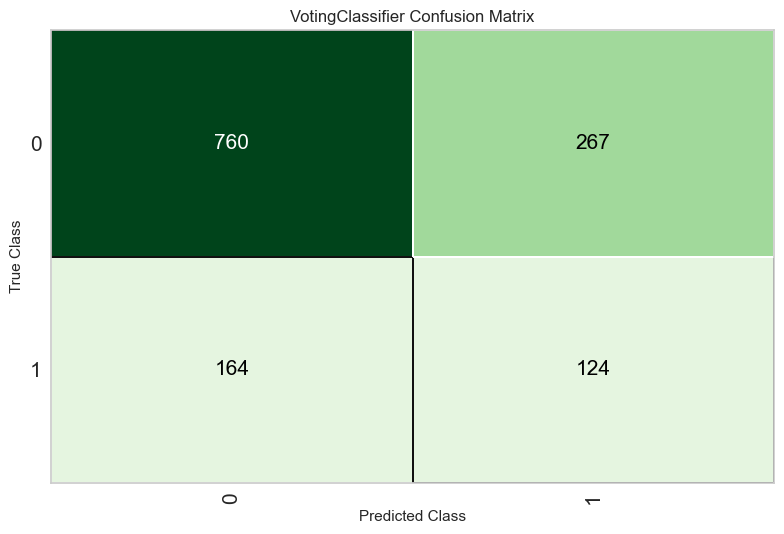

In [31]:
plot_model(def_cs_tuned, plot='confusion_matrix')

### Save Model


In [ ]:
save_model(base_def_cs_tuned, './models/def_cs_final_model')
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

Transformation Pipeline and Model Successfully Saved


### Predictions


In [29]:
set(def_cs_data) - set(d_cs_features)

set()

In [16]:
data_36_def_cs = data_36_def[d_cs_features]
data_37_def_cs = data_37_def[d_cs_features]
data_38_def_cs = data_38_def[d_cs_features]
# Load model
d_cs_model = load_model('./models/def_cs_final_model')

Transformation Pipeline and Model Successfully Loaded


In [17]:
# data_36_def_cs.reset_index(drop=True, inplace=True)
d_cs = data_36_def_cs[['clean_sheets']].copy()
data_36_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

d_cs_preds_36 = predict_model(d_cs_model, data=data_36_def_cs)
d_cs_preds_36 = d_cs_preds_36.rename(columns={'prediction_label': 'cs_preds'})

# Add predicted to data_36_def
data_36_def['cs_preds'] = d_cs_preds_36['cs_preds']

# Generate a confusion matrix
cm = confusion_matrix(d_cs_preds_36['cs_preds'], d_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Defenders' Actual vs Predicted Clean Sheets for GW 36")
plt.show()


KeyError: "['expected_goals_3', 'expected_goals_4', 'expected_goals_5'] not in index"

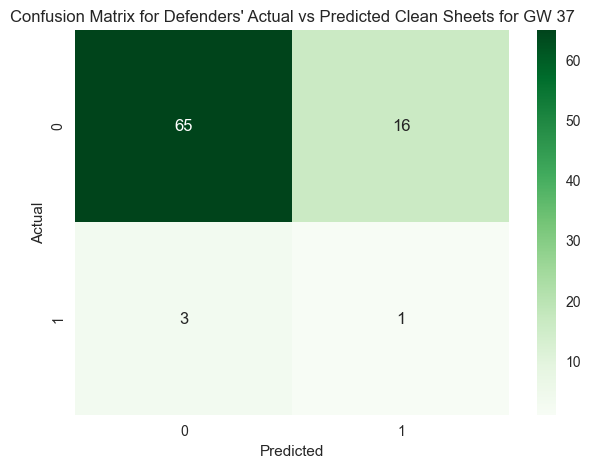

In [ ]:

# data_37_def_cs.reset_index(drop=True, inplace=True)
d_cs = data_37_def_cs[['clean_sheets']].copy()
data_37_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

d_cs_preds_37 = predict_model(d_cs_model, data=data_37_def_cs)
d_cs_preds_37 = d_cs_preds_37.rename(columns={'prediction_label': 'cs_preds'})

# Add predicted to data_37_def
data_37_def['cs_preds'] = d_cs_preds_37['cs_preds']

# Generate a confusion matrix
cm = confusion_matrix(d_cs_preds_37['cs_preds'], d_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Defenders' Actual vs Predicted Clean Sheets for GW 37")
plt.show()


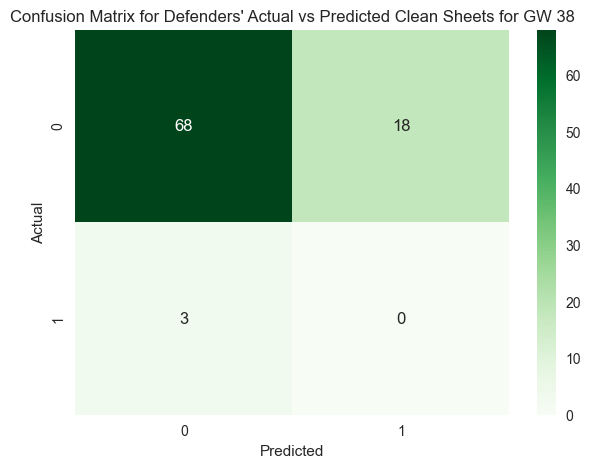

In [ ]:
# data_38_def_cs.reset_index(drop=True, inplace=True)
d_cs = data_38_def_cs[['clean_sheets']].copy()
data_38_def_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

d_cs_preds_38 = predict_model(d_cs_model, data=data_38_def_cs)
d_cs_preds_38 = d_cs_preds_38.rename(columns={'prediction_label': 'cs_preds'})

# Add predicted to data_38_def
data_38_def['cs_preds'] = d_cs_preds_38['cs_preds']

# Generate a confusion matrix
cm = confusion_matrix(d_cs_preds_38['cs_preds'], d_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Defenders' Actual vs Predicted Clean Sheets for GW 38")
plt.show()

## Mid


In [ ]:
mid_cs_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
                 'clean_sheets',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]

mid_cs_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
mid_cs_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_cs_data = mid_cs_data[mid_cs_features]
mid_cs_data_tar = mid_cs_data_tar[mid_cs_features]

mid_cs_data.reset_index(drop=True, inplace=True)
mid_cs_data.reset_index(drop=True, inplace=True)

mid_cs_data.drop(columns=['position'], inplace=True)
mid_cs_data_tar.drop(columns=['position', 'clean_sheets'], inplace=True)


clean_sheets
0    5131
1    1442
Name: count, dtype: int64


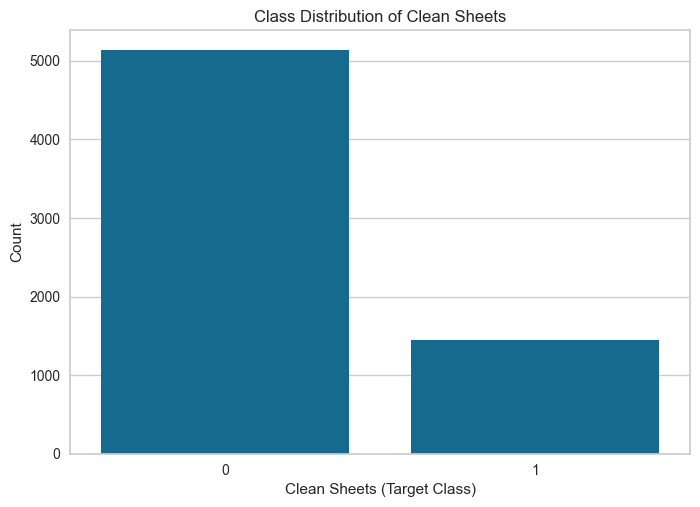

In [36]:
print(mid_cs_data['clean_sheets'].value_counts())
sns.countplot(x='clean_sheets', data=mid_cs_data)
plt.title('Class Distribution of Clean Sheets')
plt.xlabel('Clean Sheets (Target Class)')
plt.ylabel('Count')
plt.show()

### Base


In [37]:
base_mid_cs_model = setup(mid_cs_data, target = 'clean_sheets',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_mid_cs_best = base_mid_cs_model.compare_models(sort='AUC')
base_mid_cs_best

[LightGBM] [Info] Number of positive: 4104, number of negative: 4104
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.016181 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 17116
[LightGBM] [Info] Number of data points in the train set: 8208, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,6173
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(9523, 24)"
5,Transformed train set shape,"(8208, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,114
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.8678,0.8764,0.5131,0.8152,0.6288,0.5537,0.5761,2.0240
rf,Random Forest Classifier,0.8465,0.8393,0.3613,0.8543,0.5051,0.4325,0.4896,2.5050
xgboost,Extreme Gradient Boosting,0.8336,0.8167,0.3890,0.7252,0.5038,0.4154,0.4456,1.6670
lightgbm,Light Gradient Boosting Machine,0.8222,0.7950,0.2678,0.7814,0.3964,0.3207,0.3852,2.8780
knn,K Neighbors Classifier,0.5942,0.7272,0.7653,0.3218,0.4529,0.2082,0.2582,1.6560
gbc,Gradient Boosting Classifier,0.7820,0.6766,0.0529,0.5298,0.0959,0.0590,0.1121,4.2190
lr,Logistic Regression,0.6018,0.6294,0.5755,0.2927,0.3880,0.1369,0.1543,2.6390
ridge,Ridge Classifier,0.5999,0.6275,0.5660,0.2890,0.3826,0.1301,0.1465,1.3710
dt,Decision Tree Classifier,0.7273,0.6259,0.4453,0.3948,0.4177,0.2409,0.2420,1.4250
lda,Linear Discriminant Analysis,0.6038,0.6256,0.5790,0.2947,0.3904,0.1407,0.1586,2.0910


ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                     criterion='gini', max_depth=None, max_features='sqrt',
                     max_leaf_nodes=None, max_samples=None,
                     min_impurity_decrease=0.0, min_samples_leaf=1,
                     min_samples_split=2, min_weight_fraction_leaf=0.0,
                     monotonic_cst=None, n_estimators=100, n_jobs=-1,
                     oob_score=False, random_state=6173, verbose=0,
                     warm_start=False)

In [38]:
evaluate_model(base_mid_cs_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [39]:
# pcc.plot_model(tuned, plot='threshold')
predict_model(base_mid_cs_best, raw_score=True)

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Extra Trees Classifier,0.8798,0.9047,0.5521,0.8457,0.6681,0.5986,0.6189


,whh,whd,wha,was_home,team_h_difficulty,team_a_difficulty,ownership_change,percenatge_net_transfers,ict_index,influence,...,team_a_score_5,team_h_score_5,total_points_5,xGChain_5,xGBuildup_5,xP_5,clean_sheets,prediction_label,prediction_score_0,prediction_score_1
2811,0.225,0.236,0.539,False,3,2,124132.0,0.490583,3.4,15.6,...,2.0,1.8,6.2,0.92,0.79,5.40,0,0,0.85,0.15
4316,0.571,0.238,0.191,True,2,3,-888.0,0.103102,2.4,13.0,...,1.0,2.6,2.4,0.55,0.55,2.22,0,0,0.78,0.22
4181,0.498,0.238,0.264,False,2,4,-13354.0,0.479855,3.6,10.0,...,2.4,1.4,3.8,0.46,0.32,0.86,0,0,0.78,0.22
2544,0.365,0.263,0.372,False,2,2,3299.0,0.623311,1.5,14.4,...,0.0,2.4,3.6,0.34,0.28,4.00,0,0,0.72,0.28
2554,0.410,0.286,0.304,True,2,2,12141.0,0.532146,1.7,2.2,...,0.6,1.8,1.8,0.02,0.02,1.08,0,0,0.62,0.38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6045,0.684,0.199,0.118,True,1,4,323302.0,0.830489,5.3,34.0,...,1.6,0.4,7.4,0.30,0.25,5.76,0,0,0.90,0.10
794,0.197,0.260,0.542,True,3,2,-23423.0,-0.724034,2.6,23.6,...,1.2,1.2,2.8,0.29,0.27,2.64,0,0,0.66,0.34
2550,0.079,0.127,0.794,True,4,2,13387.0,0.522468,1.7,16.4,...,1.0,2.8,1.0,0.05,0.05,0.54,0,0,0.89,0.11
1660,0.657,0.225,0.118,True,2,3,0.0,0.944165,7.9,26.0,...,0.8,1.6,5.6,0.76,0.70,7.98,1,1,0.44,0.56


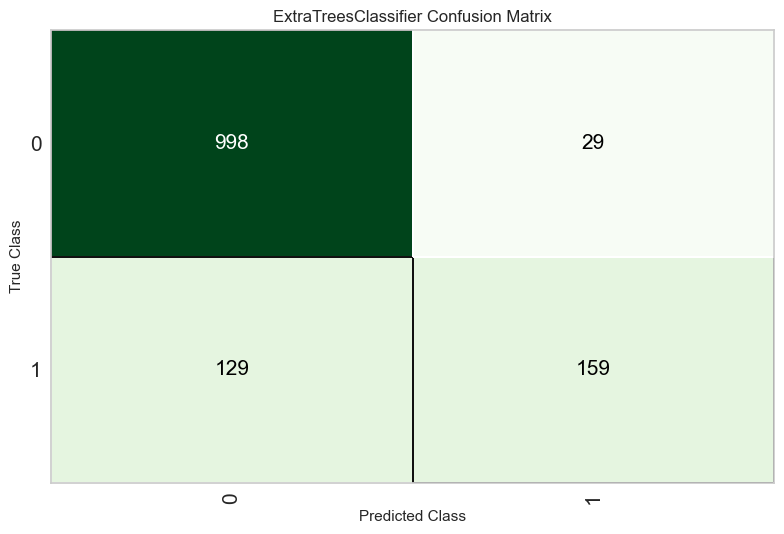

In [40]:

plot_model(base_mid_cs_best, plot='confusion_matrix')

In [41]:
base_mid_cs_tuned = tune_model(base_mid_cs_best, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7700,0.7257,0.4000,0.4694,0.4319,0.2889,0.2903
1,0.7681,0.7534,0.3652,0.4615,0.4078,0.2660,0.2688
2,0.7529,0.7162,0.2957,0.4096,0.3434,0.1961,0.2000
3,0.7719,0.7565,0.3565,0.4713,0.4059,0.2681,0.2721
4,0.7433,0.6773,0.3534,0.4059,0.3779,0.2172,0.2180
5,0.7605,0.7398,0.4138,0.4528,0.4324,0.2810,0.2815
6,0.7586,0.7368,0.2845,0.4286,0.3420,0.2014,0.2078
7,0.7795,0.7306,0.3707,0.5000,0.4257,0.2930,0.2980
8,0.7600,0.7346,0.4435,0.4513,0.4474,0.2941,0.2941


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Tuned


In [43]:
# Enhanced setup for better performance

def _reorder_cols(self, df, original_df):
    return df  # Disable column reordering to avoid IndexError

TransformerWrapper._reorder_cols = _reorder_cols

tuned_mid_cs_model = setup(mid_cs_data, target='clean_sheets',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

mid_cs_best = tuned_mid_cs_model.compare_models(n_select=3, sort='F1')
mid_cs_best

,Description,Value
0,Session id,123
1,Target,clean_sheets
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(4543, 65)"
5,Transformed train set shape,"(3228, 65)"
6,Transformed test set shape,"(1315, 65)"
7,Numeric features,114
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
et,Extra Trees Classifier,0.7094,0.7024,0.4956,0.3788,0.4288,0.2390,0.2431,1.0830
lr,Logistic Regression,0.5289,0.6297,0.7104,0.2765,0.3978,0.1201,0.1578,0.7350
rf,Random Forest Classifier,0.7162,0.6905,0.4218,0.3702,0.3932,0.2094,0.2108,1.6030
ridge,Ridge Classifier,0.5204,0.6243,0.7078,0.2721,0.3929,0.1113,0.1471,0.9320
xgboost,Extreme Gradient Boosting,0.7160,0.6921,0.4177,0.3716,0.3920,0.2082,0.2094,1.1650
lda,Linear Discriminant Analysis,0.5175,0.6227,0.7026,0.2696,0.3895,0.1062,0.1410,0.6670
lightgbm,Light Gradient Boosting Machine,0.7282,0.7011,0.3934,0.3839,0.3882,0.2137,0.2139,3.0020
knn,K Neighbors Classifier,0.4186,0.6015,0.8231,0.2498,0.3833,0.0702,0.1185,0.7550
svm,SVM - Linear Kernel,0.5215,0.5878,0.6551,0.2638,0.3754,0.0913,0.1161,0.8070
dt,Decision Tree Classifier,0.6350,0.5849,0.4955,0.3004,0.3736,0.1380,0.1466,0.8860


[ExtraTreesClassifier(bootstrap=False, ccp_alpha=0.0, class_weight=None,
                      criterion='gini', max_depth=None, max_features='sqrt',
                      max_leaf_nodes=None, max_samples=None,
                      min_impurity_decrease=0.0, min_samples_leaf=1,
                      min_samples_split=2, min_weight_fraction_leaf=0.0,
                      monotonic_cst=None, n_estimators=100, n_jobs=-1,
                      oob_score=False, random_state=123, verbose=0,
                      warm_start=False),
 LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                    intercept_scaling=1, l1_ratio=None, max_iter=1000,
                    multi_class='auto', n_jobs=None, penalty='l2',
                    random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                    warm_start=False),
 RandomForestClassifier(bootstrap=True, ccp_alpha=0.0, class_weight=None,
                        criterion='gini', max_depth=None, max

In [44]:
# Ensemble (blend or stack)
mid_cs_blended = blend_models(mid_cs_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6388,0.7004,0.6552,0.3363,0.4444,0.2159,0.2423
1,0.6331,0.7045,0.6379,0.3289,0.4340,0.2017,0.2260
2,0.6198,0.6803,0.6466,0.3205,0.4286,0.1896,0.2159
3,0.6331,0.6697,0.6207,0.3258,0.4273,0.1942,0.2161
4,0.7053,0.7448,0.7130,0.4020,0.5141,0.3255,0.3530
5,0.6179,0.6435,0.5391,0.2952,0.3815,0.1380,0.1511
6,0.6331,0.6741,0.5391,0.3069,0.3912,0.1560,0.1687
7,0.6274,0.6975,0.5565,0.3062,0.3951,0.1574,0.1721
8,0.6076,0.6583,0.5826,0.2978,0.3941,0.1467,0.1649


In [45]:
mid_cs_tuned = tune_model(mid_cs_blended, search_library='optuna', optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.6407,0.6993,0.6034,0.3286,0.4255,0.1959,0.2151
1,0.5989,0.6987,0.6810,0.3123,0.4282,0.1803,0.2130
2,0.5951,0.6707,0.6207,0.2988,0.4034,0.1504,0.1735
3,0.6388,0.6725,0.5776,0.3221,0.4136,0.1819,0.1982
4,0.6768,0.7298,0.6609,0.3671,0.4720,0.2656,0.2895
5,0.6217,0.6212,0.4957,0.2879,0.3642,0.1211,0.1302
6,0.6293,0.6668,0.6087,0.3182,0.4179,0.1834,0.2042
7,0.6502,0.6936,0.6348,0.3395,0.4424,0.2203,0.2432
8,0.6190,0.6641,0.5652,0.3023,0.3939,0.1519,0.1677


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


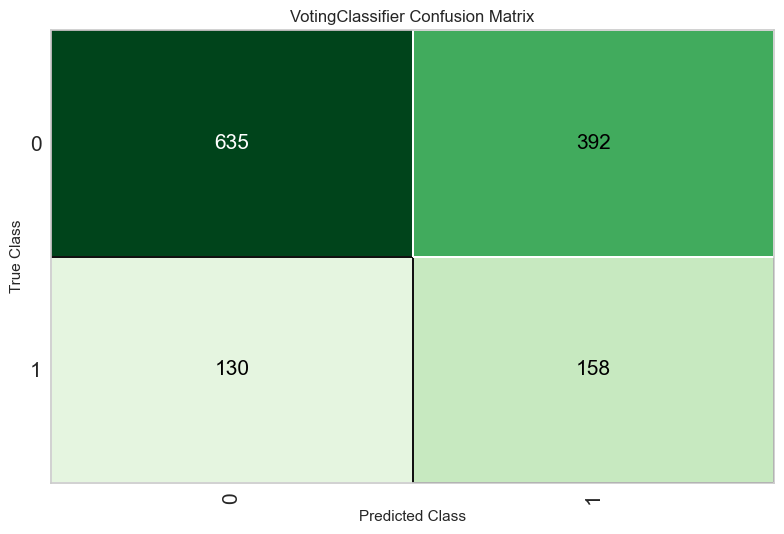

In [46]:
plot_model(mid_cs_tuned, plot='confusion_matrix')

### Save Model


In [ ]:
save_model(base_mid_cs_best, './models/mid_cs_final_model')
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

Transformation Pipeline and Model Successfully Saved


### Predictions


In [108]:
data_36_mid_cs = data_36_mid[mid_cs_features]
data_37_mid_cs = data_37_mid[mid_cs_features]
data_38_mid_cs = data_38_mid[mid_cs_features]
# Load model
mid_cs_model = load_model('./models/mid_cs_final_model')


Transformation Pipeline and Model Successfully Loaded


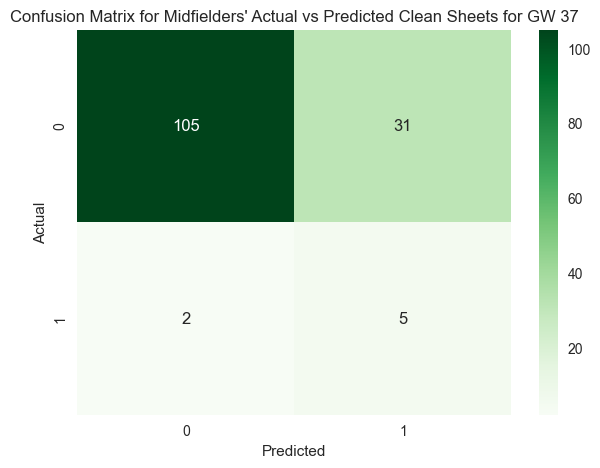

In [109]:
# data_36_mid_cs.reset_index(drop=True, inplace=True)
mid_cs = data_36_mid_cs[['clean_sheets']].copy()
data_36_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

mid_cs_preds_36 = predict_model(mid_cs_model, data=data_36_mid_cs)
mid_cs_preds_36 = mid_cs_preds_36.rename(columns={'prediction_label': 'cs_preds'})

# Add predicted to data_36_mid
data_36_mid['cs_preds'] = mid_cs_preds_36['cs_preds']

# Generate a confusion matrix
cm = confusion_matrix(mid_cs_preds_36['cs_preds'], mid_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Midfielders' Actual vs Predicted Clean Sheets for GW 37")
plt.show()


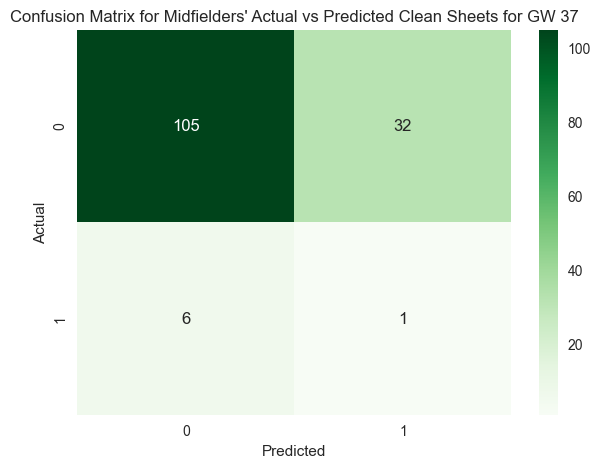

In [110]:
# data_37_mid_cs.reset_index(drop=True, inplace=True)
mid_cs = data_37_mid_cs[['clean_sheets']].copy()
data_37_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

mid_cs_preds_37 = predict_model(mid_cs_model, data=data_37_mid_cs)
mid_cs_preds_37 = mid_cs_preds_37.rename(columns={'prediction_label': 'cs_preds'})

# Add predicted to data_37_mid
data_37_mid['cs_preds'] = mid_cs_preds_37['cs_preds']

# Generate a confusion matrix
cm = confusion_matrix(mid_cs_preds_37['cs_preds'], mid_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Midfielders' Actual vs Predicted Clean Sheets for GW 37")
plt.show()

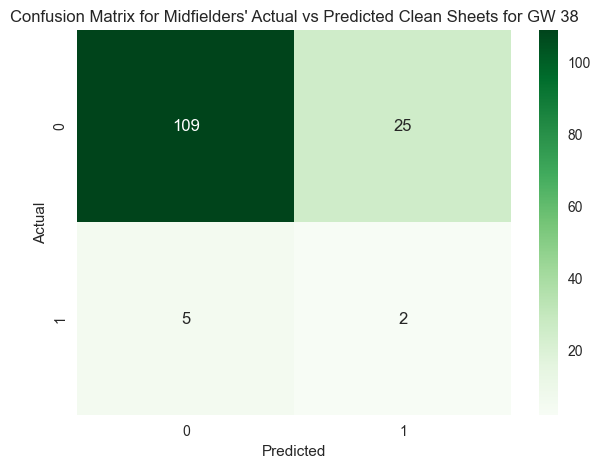

In [111]:
# data_38_mid_cs.reset_index(drop=True, inplace=True)
mid_cs = data_38_mid_cs[['clean_sheets']].copy()
data_38_mid_cs.drop(columns=['position', 'clean_sheets'], inplace=True)

mid_cs_preds_38 = predict_model(mid_cs_model, data=data_38_mid_cs)
mid_cs_preds_38 = mid_cs_preds_38.rename(columns={'prediction_label': 'cs_preds'})

# Add predicted to data_38_mid
data_38_mid['cs_preds'] = mid_cs_preds_38['cs_preds']

# Generate a confusion matrix
cm = confusion_matrix(mid_cs_preds_38['cs_preds'], mid_cs['clean_sheets'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Midfielders' Actual vs Predicted Clean Sheets for GW 38")
plt.show()


# Yellow cards


## GK


### Base Model


In [48]:
g_y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',

                'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]


g_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'GK')]
g_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '1')]

g_y_data = g_y_data[g_y_features]
g_y_data_tar = g_y_data_tar[g_y_features]

g_y_data.reset_index(drop=True, inplace=True)
g_y_data.reset_index(drop=True, inplace=True)

g_y_data.drop(columns=['position'], inplace=True)
g_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)


yellow_cards
0    1492
1     120
Name: count, dtype: int64


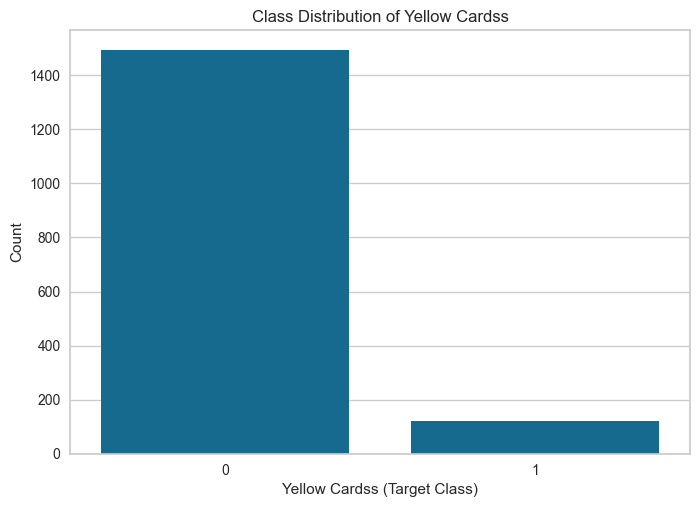

In [49]:
print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

yellow_cards
0    1492
1     120
Name: count, dtype: int64


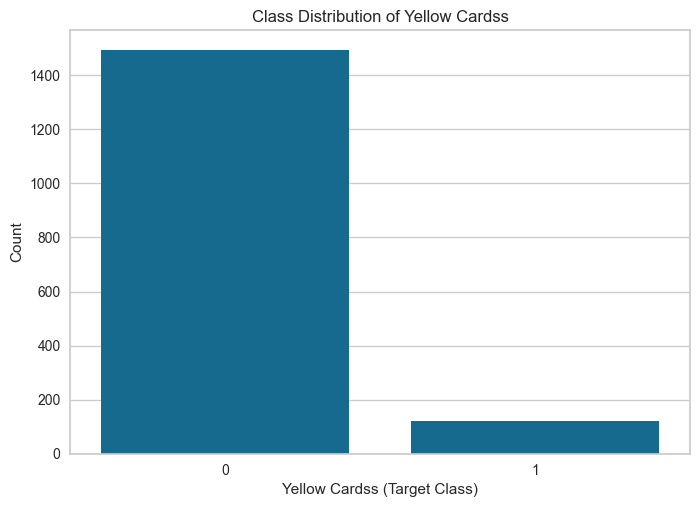

[LightGBM] [Info] Number of positive: 1193, number of negative: 1193
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003921 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 12887
[LightGBM] [Info] Number of data points in the train set: 2386, number of used features: 72
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,3267
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(2709, 24)"
5,Transformed train set shape,"(2386, 24)"
6,Transformed test set shape,"(323, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lda,Linear Discriminant Analysis,0.5904,0.5344,0.4611,0.0852,0.1434,0.0207,0.0332,1.1010
svm,SVM - Linear Kernel,0.5438,0.5239,0.4722,0.0739,0.1270,0.0001,0.0103,1.5410
ridge,Ridge Classifier,0.5997,0.5110,0.3611,0.0724,0.1203,-0.0043,-0.0093,0.9740
dummy,Dummy Classifier,0.9255,0.5000,0.0000,0.0000,0.0000,0.0000,0.0000,1.9600
lr,Logistic Regression,0.5911,0.4985,0.4044,0.0777,0.1299,0.0059,0.0071,0.9560
gbc,Gradient Boosting Classifier,0.9170,0.4904,0.0200,0.1333,0.0336,0.0163,0.0293,2.1560
rf,Random Forest Classifier,0.9185,0.4900,0.0200,0.1500,0.0348,0.0186,0.0318,1.3470
nb,Naive Bayes,0.5283,0.4736,0.4522,0.0744,0.1277,-0.0003,-0.0056,0.9630
ada,Ada Boost Classifier,0.8751,0.4715,0.0911,0.1048,0.0972,0.0317,0.0312,1.8340
et,Extra Trees Classifier,0.9170,0.4676,0.0000,0.0000,0.0000,-0.0148,-0.0228,1.7710


LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)

In [50]:
print(g_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=g_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_g_y_model = setup(g_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_g_y_best = base_g_y_model.compare_models(sort='AUC')
base_g_y_best

In [51]:
evaluate_model(base_g_y_best)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

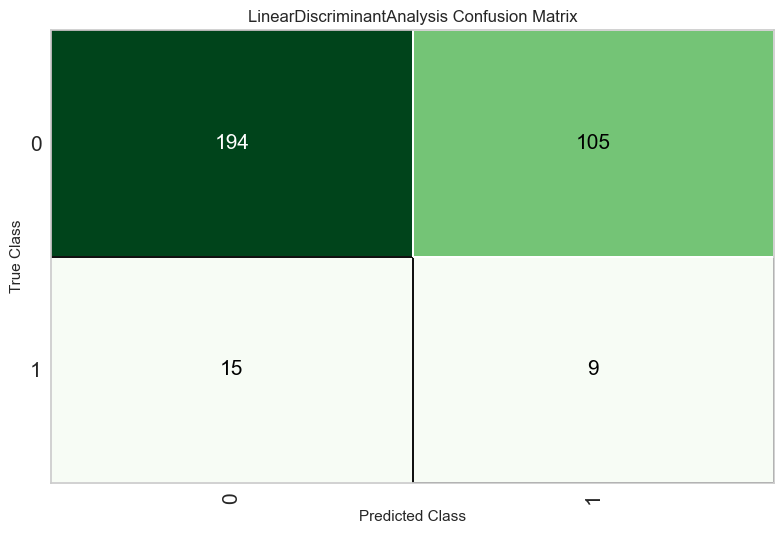

In [52]:
plot_model(base_g_y_best, plot='confusion_matrix')

### Tuned Model


In [53]:
# Enhanced setup for better performance
tuned_g_y_model = setup(g_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

g_y_best = tuned_g_y_model.compare_models(n_select=3, sort='F1')
g_y_best

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1612, 116)"
4,Transformed data shape,"(1091, 58)"
5,Transformed train set shape,"(767, 58)"
6,Transformed test set shape,"(323, 58)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dt,Decision Tree Classifier,0.7331,0.5424,0.3178,0.0937,0.1430,0.0346,0.0480,0.4920
nb,Naive Bayes,0.1652,0.5049,0.9200,0.0761,0.1406,0.0035,0.0239,0.4760
dummy,Dummy Classifier,0.1590,0.5000,0.9000,0.0667,0.1242,0.0000,0.0000,0.6950
svm,SVM - Linear Kernel,0.6354,0.5042,0.3489,0.0735,0.1209,-0.0012,0.0021,0.5860
lda,Linear Discriminant Analysis,0.6044,0.5046,0.3478,0.0691,0.1153,-0.0102,-0.0156,0.7130
gbc,Gradient Boosting Classifier,0.8363,0.5598,0.1700,0.0903,0.1150,0.0358,0.0390,1.1640
ridge,Ridge Classifier,0.6113,0.4943,0.3378,0.0690,0.1143,-0.0105,-0.0163,0.5810
knn,K Neighbors Classifier,0.5314,0.4820,0.3967,0.0647,0.1111,-0.0189,-0.0324,0.4560
lightgbm,Light Gradient Boosting Machine,0.8720,0.5520,0.1189,0.1231,0.1080,0.0472,0.0504,1.8020
lr,Logistic Regression,0.6400,0.4885,0.2833,0.0638,0.1039,-0.0197,-0.0274,0.5300


[DecisionTreeClassifier(ccp_alpha=0.0, class_weight=None, criterion='gini',
                        max_depth=None, max_features=None, max_leaf_nodes=None,
                        min_impurity_decrease=0.0, min_samples_leaf=1,
                        min_samples_split=2, min_weight_fraction_leaf=0.0,
                        monotonic_cst=None, random_state=123, splitter='best'),
 GaussianNB(priors=None, var_smoothing=1e-09),
 DummyClassifier(constant=None, random_state=123, strategy='prior')]

In [54]:


# Ensemble (blend or stack)
g_y_blended = blend_models(g_y_best, optimize='F1')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.1395,0.5028,1.0000,0.0750,0.1395,0.0112,0.0750
1,0.1240,0.5319,1.0000,0.0738,0.1374,0.0086,0.0656
2,0.1318,0.5583,1.0000,0.0744,0.1385,0.0099,0.0704
3,0.1240,0.4773,0.9000,0.0744,0.1374,-0.0068,-0.0457
4,0.1085,0.3311,0.5000,0.0435,0.0800,-0.0731,-0.3648
5,0.1318,0.4731,0.9000,0.0750,0.1385,-0.0054,-0.0344
6,0.1628,0.4727,1.0000,0.0847,0.1562,0.0155,0.0885
7,0.7829,0.4139,0.1000,0.0500,0.0667,-0.0409,-0.0441
8,0.7907,0.4845,0.1000,0.0526,0.0690,-0.0363,-0.0387


In [55]:

g_y_tuned = tune_model(g_y_blended, search_library='optuna', optimize='F1')


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7597,0.5380,0.2222,0.0769,0.1143,0.0119,0.0141
1,0.7597,0.5389,0.2222,0.0769,0.1143,0.0119,0.0141
2,0.7674,0.4833,0.0000,0.0000,0.0000,-0.1082,-0.1208
3,0.7209,0.4782,0.2000,0.0667,0.1000,-0.0184,-0.0223
4,0.7752,0.2521,0.0000,0.0000,0.0000,-0.1131,-0.1205
5,0.7674,0.4887,0.2000,0.0833,0.1176,0.0092,0.0104
6,0.7364,0.5437,0.3000,0.1000,0.1500,0.0382,0.0463
7,0.8527,0.5202,0.2000,0.1538,0.1739,0.0946,0.0956
8,0.7364,0.4672,0.2000,0.0714,0.1053,-0.0101,-0.0120


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


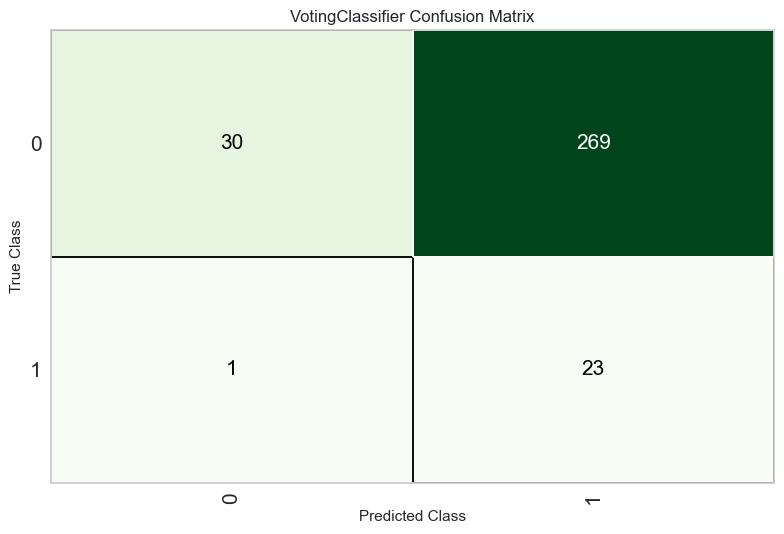

In [56]:
plot_model(g_y_tuned, plot='confusion_matrix')

In [57]:
# pcc.plot_model(tuned, plot='threshold')
preds_blend = predict_model(g_y_blended, raw_score=True)

# pcc.plot_model(tuned, plot='threshold')
preds = predict_model(g_y_tuned, raw_score=True)


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.1641,0.5017,0.9583,0.0788,0.1456,0.0096,0.0522


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Voting Classifier,0.1641,0.5017,0.9583,0.0788,0.1456,0.0096,0.0522


In [58]:

# Get feature selection results
selected_features = get_config('X_train').columns.tolist()
print("Selected features:", selected_features)

Selected features: ['whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'ict_index', 'influence', 'creativity', 'threat', 'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1', 'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1', 'yellow_cards_1', 'saves_1', 'starts_1', 'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1', 'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2', 'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2', 'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2', 'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3', 'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_g

In [59]:
evaluate_model(g_y_blended)

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

### Save Model


In [60]:

# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols


In [61]:
g_y_final_model = finalize_model(g_y_blended)
save_model(g_y_final_model, './models/g_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                       min_samples_leaf=1,
           

### Predictions


In [158]:
data_36_gk_y = data_36_mid[g_y_features]
data_37_gk_y = data_37_mid[g_y_features]
data_38_gk_y = data_38_mid[g_y_features]
# Load model
gk_y_model = load_model('./models/g_y_final_model')

Transformation Pipeline and Model Successfully Loaded


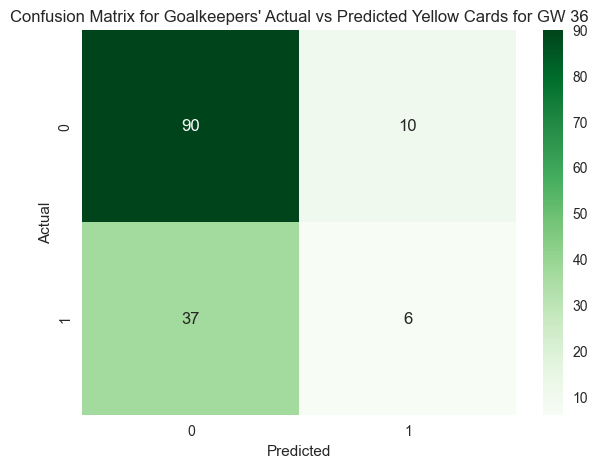

In [159]:
# data_36_gk_y.reset_index(drop=True, inplace=True)
gk_y = data_36_gk_y[['yellow_cards']].copy()
data_36_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

gk_y_preds_36 = predict_model(gk_y_model, data=data_36_gk_y)
gk_y_preds_36 = gk_y_preds_36.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_36_def
data_36_def['yc_preds'] = gk_y_preds_36['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(gk_y_preds_36['yc_preds'], gk_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Goalkeepers' Actual vs Predicted Yellow Cards for GW 36")
plt.show()

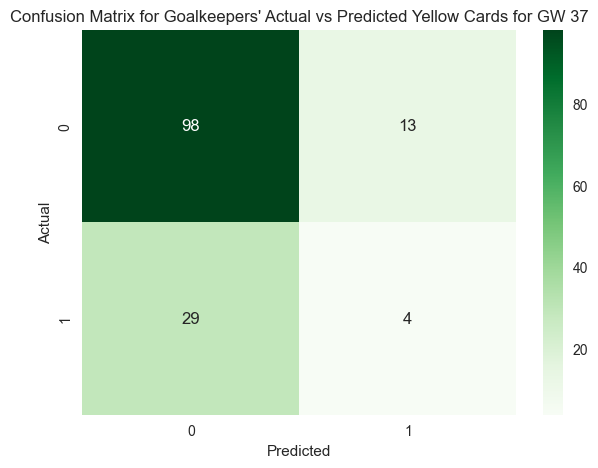

In [160]:
# data_37_gk_y.reset_index(drop=True, inplace=True)
gk_y = data_37_gk_y[['yellow_cards']].copy()
data_37_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

gk_y_preds_37 = predict_model(gk_y_model, data=data_37_gk_y)
gk_y_preds_37 = gk_y_preds_37.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_37_def
data_37_def['yc_preds'] = gk_y_preds_37['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(gk_y_preds_37['yc_preds'], gk_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Goalkeepers' Actual vs Predicted Yellow Cards for GW 37")
plt.show()

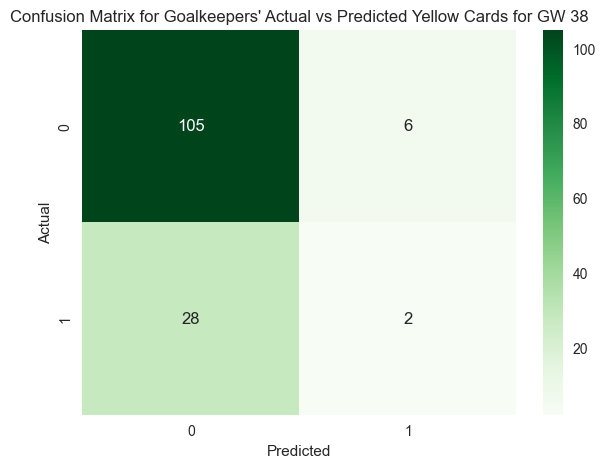

In [161]:
# data_38_gk_y.reset_index(drop=True, inplace=True)
gk_y = data_38_gk_y[['yellow_cards']].copy()
data_38_gk_y.drop(columns=['position', 'yellow_cards'], inplace=True)

gk_y_preds_38 = predict_model(gk_y_model, data=data_38_gk_y)
gk_y_preds_38 = gk_y_preds_38.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_38_def
data_38_def['yc_preds'] = gk_y_preds_38['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(gk_y_preds_38['yc_preds'], gk_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Goalkeepers' Actual vs Predicted Yellow Cards for GW 38")
plt.show()

## Def


### Base Model


In [63]:
d_y_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



def_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'DEF')]
def_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '2')]

def_y_data = def_y_data[d_y_features]
def_y_data_tar = def_y_data_tar[d_y_features]

def_y_data.reset_index(drop=True, inplace=True)
def_y_data.reset_index(drop=True, inplace=True)

def_y_data.drop(columns=['position'], inplace=True)
def_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

yellow_cards
0    5581
1     992
Name: count, dtype: int64


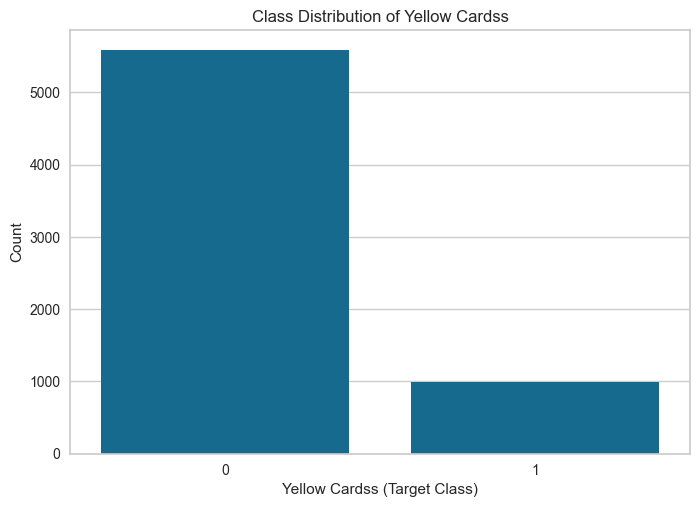

[LightGBM] [Info] Number of positive: 4464, number of negative: 4464
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.052438 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17732
[LightGBM] [Info] Number of data points in the train set: 8928, number of used features: 79
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,5436
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(10243, 24)"
5,Transformed train set shape,"(8928, 24)"
6,Transformed test set shape,"(1315, 24)"
7,Numeric features,114
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
nb,Naive Bayes,0.4618,0.5372,0.6384,0.1662,0.2637,0.0317,0.0499,2.1350
svm,SVM - Linear Kernel,0.4819,0.5230,0.5735,0.1602,0.2490,0.0188,0.0287,2.4380
lda,Linear Discriminant Analysis,0.5264,0.5297,0.5138,0.1625,0.2468,0.0226,0.0305,1.8970
knn,K Neighbors Classifier,0.4836,0.5228,0.5565,0.1574,0.2454,0.0132,0.0196,1.8470
lr,Logistic Regression,0.5133,0.5210,0.5112,0.1578,0.2411,0.0133,0.0179,2.7540
qda,Quadratic Discriminant Analysis,0.5240,0.5258,0.4999,0.1584,0.2403,0.0146,0.0202,2.0670
ridge,Ridge Classifier,0.5167,0.5138,0.4925,0.1549,0.2355,0.0074,0.0097,1.9510
dt,Decision Tree Classifier,0.7185,0.5066,0.2029,0.1600,0.1787,0.0119,0.0120,2.6070
ada,Ada Boost Classifier,0.8091,0.5282,0.0554,0.1552,0.0723,-0.0027,-0.0022,2.8400
rf,Random Forest Classifier,0.8416,0.5315,0.0352,0.2992,0.0608,0.0308,0.0524,5.0770


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4525,0.5224,0.5949,0.1551,0.2461,0.0103,0.0161
1,0.4240,0.4731,0.5696,0.1433,0.2290,-0.0145,-0.0234
2,0.4848,0.5170,0.5063,0.1471,0.2279,-0.0063,-0.0091
3,0.4620,0.5303,0.6456,0.1667,0.2649,0.0344,0.0544
4,0.5114,0.6098,0.7375,0.2000,0.3147,0.0991,0.1508
5,0.4506,0.4865,0.5875,0.1551,0.2454,0.0063,0.0098
6,0.4544,0.5747,0.6125,0.1607,0.2545,0.0179,0.0280
7,0.4487,0.5874,0.7125,0.1759,0.2822,0.0506,0.0841
8,0.4571,0.5416,0.6329,0.1634,0.2597,0.0270,0.0427


In [64]:
print(def_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=def_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_def_y_model = setup(def_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_def_y_best = base_def_y_model.compare_models(sort='F1')
base_def_y_best

print('Tuning the model...')
def_y_base_tuned = tune_model(base_def_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

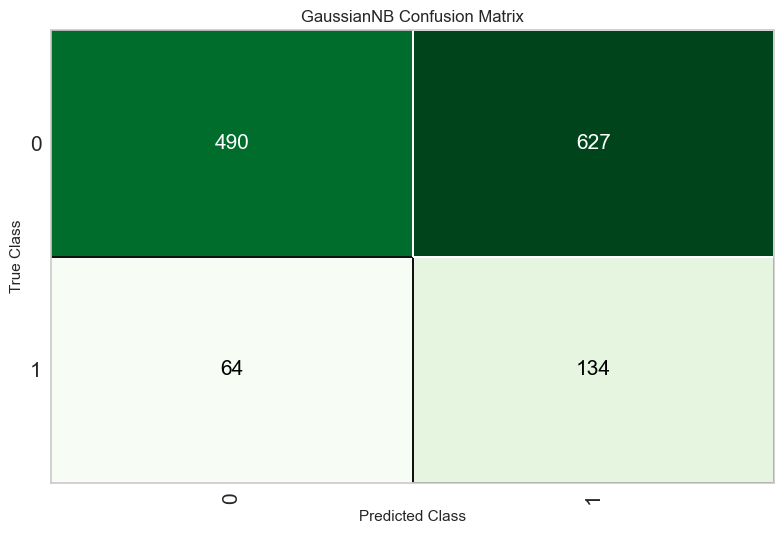

In [65]:
evaluate_model(base_def_y_best)
plot_model(base_def_y_best, plot='confusion_matrix')

### Blended Model


In [66]:
# Enhanced setup for better performance
tuned_def_y_model = setup(def_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

def_y_best = tuned_def_y_model.compare_models(n_select=3, sort='F1')
print(def_y_best)

print('Blended model')
# Ensemble (blend or stack)
def_y_blended = blend_models(def_y_best, optimize='F1')

def_y_tuned = tune_model(def_y_blended, search_library='optuna', optimize='F1')

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(6573, 116)"
4,Transformed data shape,"(5106, 65)"
5,Transformed train set shape,"(3812, 65)"
6,Transformed test set shape,"(1315, 65)"
7,Numeric features,114
8,Rows with missing values,0.0%
9,Preprocess,True


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.1510,0.5000,1.0000,0.1510,0.2624,0.0000,0.0000,0.9910
nb,Naive Bayes,0.4722,0.5374,0.6019,0.1627,0.2561,0.0242,0.0369,0.8820
lr,Logistic Regression,0.3241,0.5045,0.7709,0.1535,0.2559,0.0056,0.0135,0.9420
knn,K Neighbors Classifier,0.3252,0.5116,0.7681,0.1536,0.2559,0.0057,0.0117,0.8100
lda,Linear Discriminant Analysis,0.3366,0.5017,0.7480,0.1531,0.2541,0.0045,0.0092,0.9020
ridge,Ridge Classifier,0.3062,0.5061,0.7734,0.1502,0.2515,-0.0017,-0.0016,1.4310
svm,SVM - Linear Kernel,0.3977,0.4949,0.6384,0.1496,0.2422,-0.0029,-0.0051,1.1240
qda,Quadratic Discriminant Analysis,0.5692,0.5060,0.4317,0.1592,0.2273,0.0143,0.0197,0.9390
ada,Ada Boost Classifier,0.6666,0.5383,0.3071,0.1685,0.2170,0.0280,0.0302,1.6170
dt,Decision Tree Classifier,0.6301,0.5005,0.3148,0.1517,0.2044,0.0010,0.0009,1.2480


[DummyClassifier(constant=None, random_state=123, strategy='prior'), GaussianNB(priors=None, var_smoothing=1e-09), LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)]
Blended model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4259,0.5331,0.6835,0.1631,0.2634,0.0276,0.0472
1,0.4087,0.4719,0.6329,0.1506,0.2433,0.0009,0.0015
2,0.4259,0.5190,0.6203,0.1526,0.2450,0.0052,0.0086
3,0.4411,0.5608,0.6456,0.1609,0.2576,0.0225,0.0369
4,0.4468,0.5996,0.7500,0.1813,0.2920,0.0622,0.1059
5,0.4677,0.5189,0.6125,0.1644,0.2593,0.0256,0.0393
6,0.4392,0.5419,0.6500,0.1630,0.2607,0.0231,0.0377
7,0.4259,0.4863,0.6375,0.1574,0.2525,0.0113,0.0187
8,0.4438,0.5446,0.6456,0.1619,0.2589,0.0241,0.0391


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.1825,0.4815,0.9747,0.1525,0.2637,0.0053,0.0314
1,0.1787,0.5192,0.9620,0.1505,0.2603,0.0007,0.0042
2,0.1939,0.5088,0.9367,0.1501,0.2587,-0.0002,-0.0010
3,0.2167,0.4825,0.8987,0.1495,0.2563,-0.0017,-0.0061
4,0.1901,0.5807,0.9625,0.1540,0.2655,0.0045,0.0233
5,0.1958,0.4885,0.9250,0.1507,0.2592,-0.0032,-0.0144
6,0.1711,0.4832,0.9125,0.1454,0.2509,-0.0156,-0.0850
7,0.1882,0.4542,0.9500,0.1523,0.2625,0.0005,0.0026
8,0.2076,0.5443,0.9241,0.1511,0.2598,0.0015,0.0063


### Save Model


In [67]:
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols
def_y_final_model = finalize_model(base_g_y_best)
save_model(def_y_final_model, './models/def_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                  random_state=None,
 

### Predicitions


In [165]:
data_36_def_y = data_36_def[d_y_features]
data_37_def_y = data_37_def[d_y_features]
data_38_def_y = data_38_def[d_y_features]
# Load model
def_y_model = load_model('./models/def_cs_final_model')


Transformation Pipeline and Model Successfully Loaded


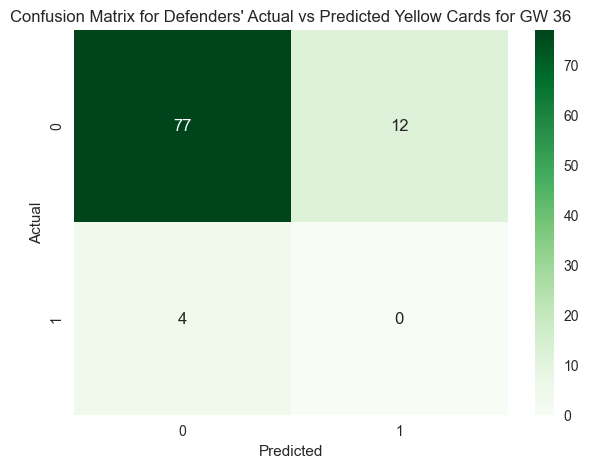

In [166]:
# data_36_def_y.reset_index(drop=True, inplace=True)
def_y = data_36_def_y[['yellow_cards']].copy()
data_36_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

def_y_preds_36 = predict_model(def_y_model, data=data_36_def_y)
def_y_preds_36 = def_y_preds_36.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_36_def
data_36_def['yc_preds'] = def_y_preds_36['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(def_y_preds_36['yc_preds'], def_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Defenders' Actual vs Predicted Yellow Cards for GW 36")
plt.show()

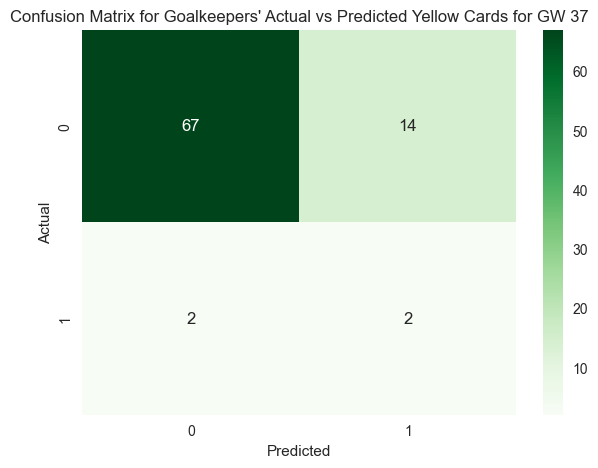

In [167]:
# data_37_def_y.reset_index(drop=True, inplace=True)
def_y = data_37_def_y[['yellow_cards']].copy()
data_37_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

def_y_preds_37 = predict_model(def_y_model, data=data_37_def_y)
def_y_preds_37 = def_y_preds_37.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_37_def
data_37_def['yc_preds'] = def_y_preds_37['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(def_y_preds_37['yc_preds'], def_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Goalkeepers' Actual vs Predicted Yellow Cards for GW 37")
plt.show()

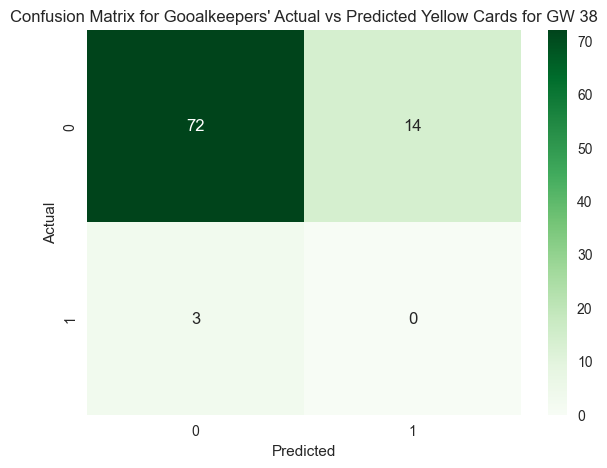

In [168]:
# data_38_def_y.reset_index(drop=True, inplace=True)
def_y = data_38_def_y[['yellow_cards']].copy()
data_38_def_y.drop(columns=['position', 'yellow_cards'], inplace=True)

def_y_preds_38 = predict_model(def_y_model, data=data_38_def_y)
def_y_preds_38 = def_y_preds_38.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_38_def
data_38_def['yc_preds'] = def_y_preds_38['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(def_y_preds_38['yc_preds'], def_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Gooalkeepers' Actual vs Predicted Yellow Cards for GW 38")
plt.show()

## Mid


In [69]:
mid_y_features = ['position', 'whh', 'whd', 'wha', 'was_home', 'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers',
            'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



mid_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'MID')]
mid_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '3')]

mid_y_data = mid_y_data[mid_y_features]
mid_y_data_tar = mid_y_data_tar[mid_y_features]

mid_y_data.reset_index(drop=True, inplace=True)
mid_y_data.reset_index(drop=True, inplace=True)

mid_y_data.drop(columns=['position'], inplace=True)
mid_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)


### Base Model


yellow_cards
0    5970
1    1106
Name: count, dtype: int64


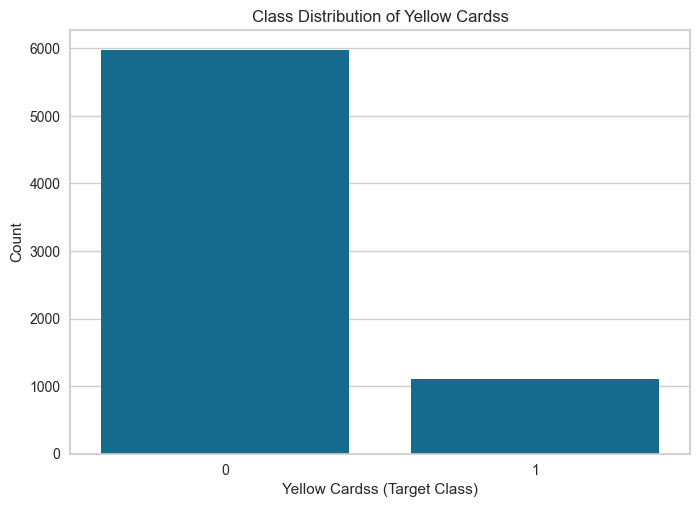

[LightGBM] [Info] Number of positive: 4775, number of negative: 4775
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.571389 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 17316
[LightGBM] [Info] Number of data points in the train set: 9550, number of used features: 78
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,5350
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(7076, 116)"
4,Transformed data shape,"(10966, 24)"
5,Transformed train set shape,"(9550, 24)"
6,Transformed test set shape,"(1416, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.5714,0.5962,0.5527,0.1941,0.2872,0.0726,0.0932,5.2800
lda,Linear Discriminant Analysis,0.5717,0.5873,0.5504,0.1940,0.2868,0.0722,0.0922,2.0360
nb,Naive Bayes,0.4652,0.5686,0.6770,0.1797,0.2839,0.0487,0.0760,2.2850
ridge,Ridge Classifier,0.5694,0.5908,0.5447,0.1917,0.2835,0.0679,0.0868,6.5440
svm,SVM - Linear Kernel,0.5535,0.5669,0.5562,0.1878,0.2799,0.0610,0.0802,3.7170
qda,Quadratic Discriminant Analysis,0.5518,0.5700,0.5436,0.1845,0.2753,0.0545,0.0707,4.6410
knn,K Neighbors Classifier,0.4673,0.5395,0.6013,0.1667,0.2609,0.0213,0.0320,7.9220
dt,Decision Tree Classifier,0.7124,0.5121,0.2206,0.1726,0.1932,0.0217,0.0220,6.4150
et,Extra Trees Classifier,0.8187,0.5710,0.0802,0.2705,0.1219,0.0506,0.0647,3.7220
xgboost,Extreme Gradient Boosting,0.8283,0.5437,0.0441,0.2312,0.0736,0.0262,0.0368,2.9740


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.5795,0.5949,0.5227,0.1901,0.2788,0.0657,0.0825
1,0.5777,0.6127,0.5795,0.2016,0.2991,0.0889,0.1144
2,0.5565,0.5952,0.5568,0.1877,0.2808,0.0629,0.0824
3,0.5830,0.6156,0.5682,0.2016,0.2976,0.0884,0.1124
4,0.6007,0.6499,0.6705,0.2305,0.3430,0.1452,0.1881
5,0.5318,0.5236,0.4944,0.1667,0.2493,0.0184,0.0242
6,0.5795,0.5697,0.5169,0.1909,0.2788,0.0638,0.0795
7,0.5583,0.5867,0.5955,0.1985,0.2978,0.0810,0.1071
8,0.6095,0.6491,0.6180,0.2273,0.3323,0.1330,0.1663


In [70]:
print(mid_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=mid_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_mid_y_model = setup(mid_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_mid_y_best = base_mid_y_model.compare_models(sort='F1')
base_mid_y_best

print('Tuning the model...')
mid_y_base_tuned = tune_model(base_mid_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

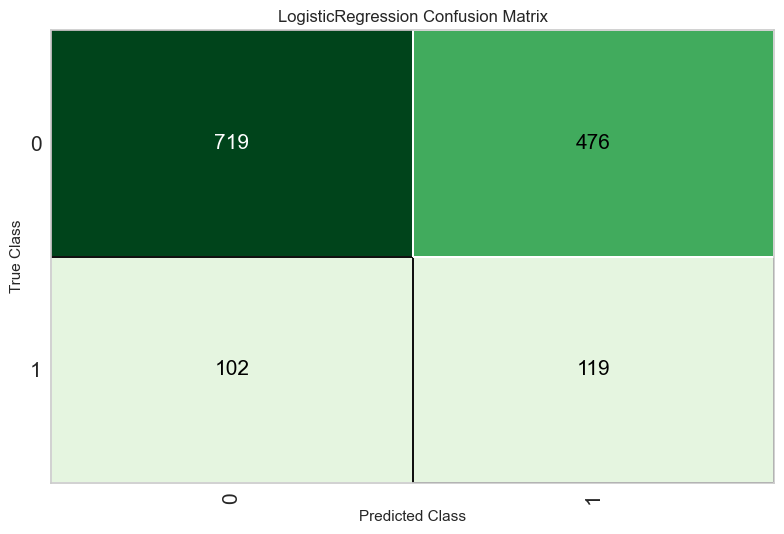

In [71]:
evaluate_model(base_mid_y_best)
plot_model(base_mid_y_best, plot='confusion_matrix')

### Blended Model


In [72]:
# Convert all boolean columns to int to avoid numpy WRITEABLE flag error
for col in mid_y_data.select_dtypes(include='bool').columns:
    mid_y_data[col] = mid_y_data[col].astype(int)

# Enhanced setup for better performance
tuned_mid_y_model = setup(mid_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

mid_y_best = tuned_mid_y_model.compare_models( sort='F1')
print(mid_y_best)

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(7076, 116)"
4,Transformed data shape,"(6248, 67)"
5,Transformed train set shape,"(4820, 67)"
6,Transformed test set shape,"(1416, 67)"
7,Numeric features,115
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lr,Logistic Regression,0.4173,0.5919,0.7694,0.1803,0.2922,0.0520,0.0938,0.6420
lda,Linear Discriminant Analysis,0.4239,0.5961,0.7603,0.1808,0.2921,0.0529,0.0933,0.7290
ridge,Ridge Classifier,0.4002,0.5968,0.7842,0.1782,0.2904,0.0477,0.0884,0.7640
svm,SVM - Linear Kernel,0.4292,0.5569,0.7050,0.1739,0.2789,0.0374,0.0626,0.6440
knn,K Neighbors Classifier,0.3263,0.5583,0.8237,0.1663,0.2767,0.0223,0.0500,0.7840
dummy,Dummy Classifier,0.1564,0.5000,1.0000,0.1564,0.2704,0.0000,0.0000,0.8000
et,Extra Trees Classifier,0.7196,0.5964,0.3163,0.2234,0.2613,0.0952,0.0974,1.2350
nb,Naive Bayes,0.5267,0.5747,0.5684,0.1789,0.2575,0.0452,0.0646,0.6610
ada,Ada Boost Classifier,0.6761,0.5804,0.3513,0.1987,0.2537,0.0672,0.0715,1.5960
gbc,Gradient Boosting Classifier,0.7279,0.5931,0.2881,0.2210,0.2493,0.0875,0.0887,3.7320


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=1000,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=123, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)


### Save Model


In [73]:
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols
mid_y_final_model = finalize_model(mid_y_best)
save_model(mid_y_final_model, './models/mid_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha', 'was_home',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', '...
                  TransformerWrapper(exclude=None, include=None,
                                    

### Predictions


In [136]:
data_36_mid_y = data_36_mid[mid_y_features]
data_37_mid_y = data_37_mid[mid_y_features]
data_38_mid_y = data_38_mid[mid_y_features]
# Load model
mid_y_model = load_model('./models/mid_y_final_model')

Transformation Pipeline and Model Successfully Loaded


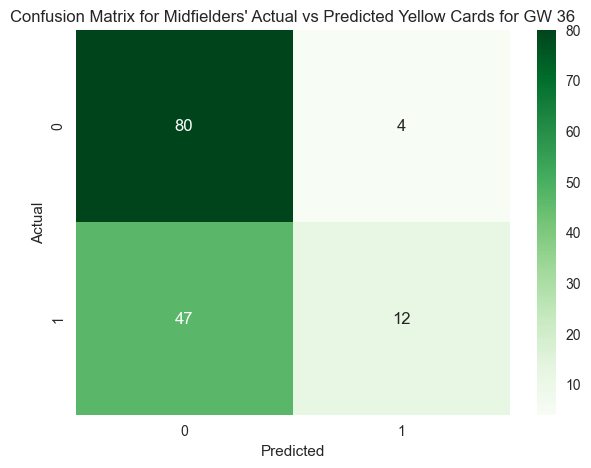

In [137]:
# data_36_mid_y.reset_index(drop=True, inplace=True)
mid_y = data_36_mid_y[['yellow_cards']].copy()
data_36_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

mid_y_preds_36 = predict_model(mid_y_model, data=data_36_mid_y)
mid_y_preds_36 = mid_y_preds_36.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_36_def
data_36_mid['yc_preds'] = mid_y_preds_36['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(mid_y_preds_36['yc_preds'], mid_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Midfielders' Actual vs Predicted Yellow Cards for GW 36")
plt.show()

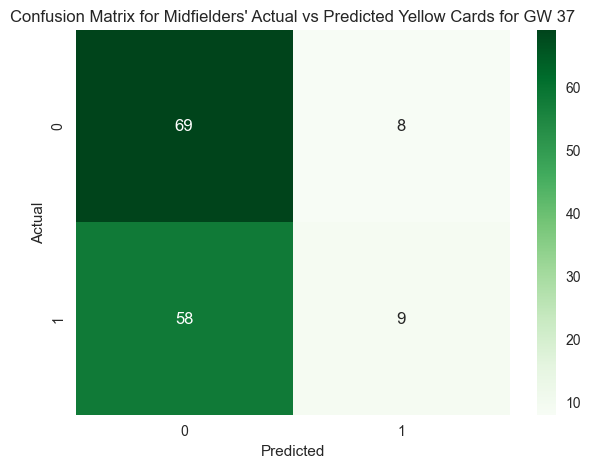

In [138]:
# data_37_mid_y.reset_index(drop=True, inplace=True)
mid_y = data_37_mid_y[['yellow_cards']].copy()
data_37_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

mid_y_preds_37 = predict_model(mid_y_model, data=data_37_mid_y)
mid_y_preds_37 = mid_y_preds_37.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_37_def
data_37_mid['yc_preds'] = mid_y_preds_37['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(mid_y_preds_37['yc_preds'], mid_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Midfielders' Actual vs Predicted Yellow Cards for GW 37")
plt.show()


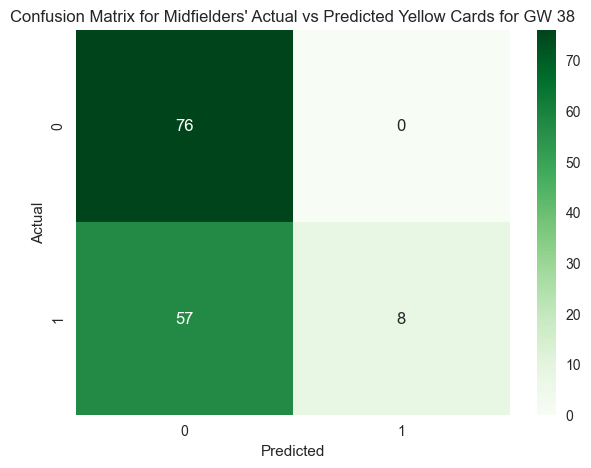

In [139]:
# data_38_mid_y.reset_index(drop=True, inplace=True)
mid_y = data_38_mid_y[['yellow_cards']].copy()
data_38_mid_y.drop(columns=['position', 'yellow_cards'], inplace=True)

mid_y_preds_38 = predict_model(mid_y_model, data=data_38_mid_y)
mid_y_preds_38 = mid_y_preds_38.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_38_def
data_38_mid['yc_preds'] = mid_y_preds_38['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(mid_y_preds_38['yc_preds'], mid_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Midfielders' Actual vs Predicted Yellow Cards for GW 38")
plt.show()


## FWD


In [75]:
fwd_y_features = [ 'position', 'whh', 'whd', 'wha', 'was_home',  'team_h_difficulty', 'team_a_difficulty', 'ownership_change', 'percenatge_net_transfers', 'yellow_cards',  'ict_index', 'influence', 'creativity', 'threat',

            'clean_sheets_1', 'expected_goals_conceded_1', 'goals_conceded_1', 'goals_scored_1', 'ict_index_1',
            'influence_1', 'creativity_1', 'threat_1', 'minutes_1', 'own_goals_1', 'penalties_saved_1',  'yellow_cards_1', 'saves_1', 'starts_1',
            'team_a_score_1', 'team_h_score_1', 'total_points_1', 'xGChain_1', 'xGBuildup_1', 'xP_1',

            'clean_sheets_2', 'expected_goals_conceded_2', 'goals_conceded_2', 'ict_index_2',
            'influence_2', 'creativity_2', 'threat_2', 'minutes_2', 'own_goals_2', 'penalties_saved_2', 'red_cards_2', 'yellow_cards_2', 'saves_2', 'starts_2',
            'team_a_score_2', 'team_h_score_2', 'total_points_2', 'xGChain_2', 'xGBuildup_2', 'xP_2',

            'clean_sheets_3', 'expected_goals_3', 'expected_goals_conceded_3', 'goals_conceded_3', 'ict_index_3',
            'influence_3', 'creativity_3', 'threat_3', 'minutes_3', 'own_goals_3', 'penalties_saved_3', 'red_cards_3', 'yellow_cards_3', 'saves_3', 'starts_3',
            'team_a_score_3', 'team_h_score_3', 'total_points_3', 'xGChain_3', 'xGBuildup_3',  'xP_3',

            'clean_sheets_4', 'expected_goals_4', 'expected_goals_conceded_4', 'goals_conceded_4', 'ict_index_4',
            'influence_4', 'creativity_4', 'threat_4', 'minutes_4', 'own_goals_4', 'penalties_saved_4', 'red_cards_4', 'yellow_cards_4', 'saves_4', 'starts_4',
            'team_a_score_4', 'team_h_score_4', 'total_points_4', 'xGChain_4', 'xGBuildup_4',  'xP_4',

            'clean_sheets_5', 'expected_goals_5', 'expected_goals_conceded_5', 'goals_conceded_5', 'ict_index_5',
            'influence_5', 'creativity_5', 'threat_5', 'minutes_5', 'own_goals_5', 'penalties_saved_5', 'red_cards_5', 'yellow_cards_5', 'saves_5', 'starts_5',
            'team_a_score_5', 'team_h_score_5', 'total_points_5',  'xGChain_5', 'xGBuildup_5',  'xP_5'
                        ]



fwd_y_data= data[(data['minutes_5'] >= 60) & (data['position'] == 'FWD')]
fwd_y_data_tar = data_tar[(data_tar['minutes_5'] >= 60) & (data_tar['position'] == '4')]

fwd_y_data = fwd_y_data[fwd_y_features]
fwd_y_data_tar = fwd_y_data_tar[fwd_y_features]

fwd_y_data.reset_index(drop=True, inplace=True)
fwd_y_data.reset_index(drop=True, inplace=True)

fwd_y_data.drop(columns=['position'], inplace=True)
fwd_y_data_tar.drop(columns=['position', 'yellow_cards'], inplace=True)

### Base Model


yellow_cards
0    1402
1     188
Name: count, dtype: int64


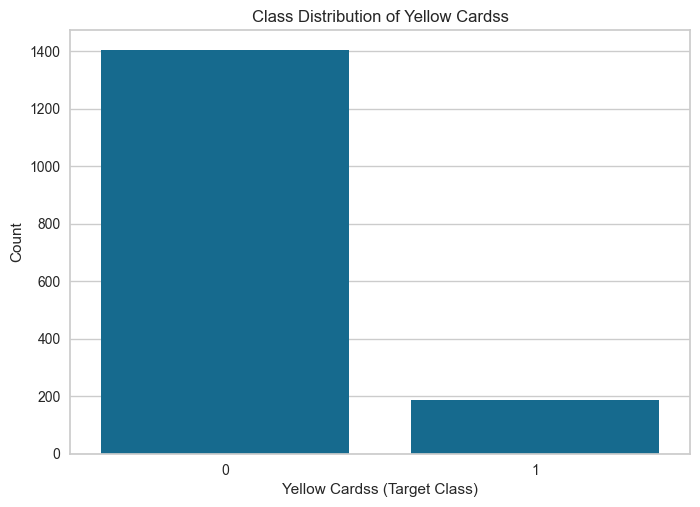

[LightGBM] [Info] Number of positive: 1122, number of negative: 1122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001597 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 15838
[LightGBM] [Info] Number of data points in the train set: 2244, number of used features: 69
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,Description,Value
0,Session id,3409
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1590, 116)"
4,Transformed data shape,"(2562, 24)"
5,Transformed train set shape,"(2244, 24)"
6,Transformed test set shape,"(318, 24)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
knn,K Neighbors Classifier,0.4843,0.5162,0.5533,0.1233,0.2013,0.0109,0.0183,0.7010
nb,Naive Bayes,0.5087,0.5074,0.5133,0.1232,0.1986,0.0102,0.0138,1.0530
qda,Quadratic Discriminant Analysis,0.6958,0.5216,0.3133,0.1430,0.1946,0.0402,0.0449,0.8560
lda,Linear Discriminant Analysis,0.5912,0.4977,0.3933,0.1183,0.1815,0.0022,0.0060,0.8630
lr,Logistic Regression,0.5668,0.4860,0.3867,0.1117,0.1730,-0.0116,-0.0150,0.5840
dt,Decision Tree Classifier,0.7688,0.5167,0.1867,0.1403,0.1593,0.0291,0.0296,0.8770
ridge,Ridge Classifier,0.5652,0.4806,0.3533,0.1022,0.1584,-0.0286,-0.0359,0.9820
svm,SVM - Linear Kernel,0.5151,0.4780,0.4067,0.0993,0.1582,-0.0340,-0.0426,0.8340
ada,Ada Boost Classifier,0.7948,0.5104,0.1600,0.1511,0.1521,0.0383,0.0386,0.8400
xgboost,Extreme Gradient Boosting,0.8624,0.5226,0.0600,0.1786,0.0888,0.0403,0.0445,0.9270


Tuning the model...


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.3906,0.4448,0.6000,0.1111,0.1875,-0.0128,-0.0248
1,0.3516,0.4737,0.6000,0.1047,0.1782,-0.0267,-0.0558
2,0.4173,0.5812,0.8667,0.1529,0.2600,0.0741,0.1535
3,0.3937,0.4696,0.7333,0.1310,0.2222,0.0273,0.0556
4,0.3858,0.5542,0.7333,0.1294,0.2200,0.0240,0.0498
5,0.3780,0.4280,0.6000,0.1098,0.1856,-0.0176,-0.0349
6,0.3307,0.6190,0.8000,0.1277,0.2202,0.0207,0.0499
7,0.3307,0.5018,0.6000,0.1023,0.1748,-0.0339,-0.0737
8,0.4094,0.4976,0.7333,0.1341,0.2268,0.0339,0.0671


In [76]:
print(fwd_y_data['yellow_cards'].value_counts())
sns.countplot(x='yellow_cards', data=fwd_y_data)
plt.title('Class Distribution of Yellow Cardss')
plt.xlabel('Yellow Cardss (Target Class)')
plt.ylabel('Count')
plt.show()

base_fwd_y_model = setup(fwd_y_data, target = 'yellow_cards',

                    train_size=0.8,
                    fix_imbalance=True,  # Handle class imbalance
                    # optimize='AUC',      # Focus on AUC-ROC
                    remove_multicollinearity=True,  # Drop collinear features
                    feature_selection=True,        # Auto-select important features
                    # Feature selection is done differently
                    normalize=True
                )

base_fwd_y_best = base_fwd_y_model.compare_models(sort='F1')
base_fwd_y_best

print('Tuning the model...')
fwd_y_base_tuned = tune_model(base_fwd_y_best, search_library='optuna', optimize='F1')

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

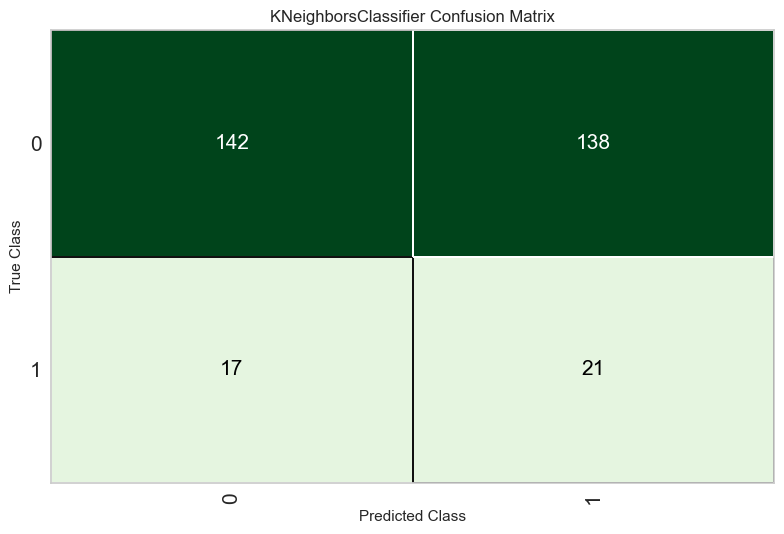

In [77]:
evaluate_model(base_fwd_y_best)
plot_model(base_fwd_y_best, plot='confusion_matrix')

### Blended Model


In [78]:
# Enhanced setup for better performance
tuned_fwd_y_model = setup(fwd_y_data, target='yellow_cards',
                train_size=0.8,

                # Imbalance handling
                fix_imbalance=True,
                fix_imbalance_method=SMOTEENN(),  # Specify SMOTE method

                # Feature preprocessing
                remove_multicollinearity=True,
                multicollinearity_threshold=0.85,  # More aggressive

                # Normalization
                normalize=True,
                normalize_method='zscore',  # Specify method

                # Cross-validation
                fold=10,  # More folds for better validation

                # Other improvements
                remove_outliers=True,
                outliers_threshold=0.05,

                session_id=123)

fwd_y_best = tuned_fwd_y_model.compare_models(n_select=3, sort='F1')
print(fwd_y_best)

print('Blended model')
# Ensemble (blend or stack)
fwd_y_blended = blend_models(fwd_y_best, optimize='F1')

fwd_y_tuned = tune_model(fwd_y_blended, search_library='optuna', optimize='F1')

,Description,Value
0,Session id,123
1,Target,yellow_cards
2,Target type,Binary
3,Original data shape,"(1590, 116)"
4,Transformed data shape,"(1090, 64)"
5,Transformed train set shape,"(777, 64)"
6,Transformed test set shape,"(318, 64)"
7,Numeric features,114
8,Preprocess,True
9,Imputation type,simple


,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
dummy,Dummy Classifier,0.1179,0.5000,1.0000,0.1179,0.2110,0.0000,0.0000,0.2680
knn,K Neighbors Classifier,0.4017,0.5349,0.6667,0.1233,0.2080,0.0113,0.0223,0.3220
lda,Linear Discriminant Analysis,0.5543,0.5067,0.4467,0.1212,0.1906,0.0066,0.0099,0.3080
svm,SVM - Linear Kernel,0.5662,0.4742,0.4067,0.1178,0.1820,-0.0010,-0.0033,0.2350
ridge,Ridge Classifier,0.5668,0.4848,0.4133,0.1163,0.1810,-0.0021,-0.0003,0.2260
lr,Logistic Regression,0.5574,0.4837,0.4000,0.1112,0.1736,-0.0121,-0.0146,0.2670
dt,Decision Tree Classifier,0.6911,0.4957,0.2400,0.1127,0.1521,-0.0068,-0.0073,0.2810
ada,Ada Boost Classifier,0.7548,0.5089,0.1733,0.1323,0.1457,0.0109,0.0105,0.3790
xgboost,Extreme Gradient Boosting,0.8435,0.4917,0.1067,0.1823,0.1318,0.0570,0.0586,0.3810
qda,Quadratic Discriminant Analysis,0.5703,0.5388,0.3867,0.1017,0.1274,-0.0059,-0.0379,0.2760


[DummyClassifier(constant=None, random_state=123, strategy='prior'), KNeighborsClassifier(algorithm='auto', leaf_size=30, metric='minkowski',
                     metric_params=None, n_jobs=-1, n_neighbors=5, p=2,
                     weights='uniform'), LinearDiscriminantAnalysis(covariance_estimator=None, n_components=None,
                           priors=None, shrinkage=None, solver='svd',
                           store_covariance=False, tol=0.0001)]
Blended model


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4609,0.5699,0.6667,0.1351,0.2247,0.0371,0.0653
1,0.3750,0.3522,0.4000,0.0779,0.1304,-0.0818,-0.1500
2,0.3937,0.5619,0.7333,0.1310,0.2222,0.0273,0.0556
3,0.4646,0.6827,0.8667,0.1646,0.2766,0.0974,0.1846
4,0.4488,0.6280,0.6667,0.1333,0.2222,0.0316,0.0566
5,0.3465,0.4905,0.6000,0.1047,0.1782,-0.0287,-0.0604
6,0.4961,0.5708,0.6667,0.1449,0.2381,0.0547,0.0906
7,0.3937,0.3268,0.4000,0.0811,0.1348,-0.0766,-0.1356
8,0.4252,0.4411,0.5333,0.1081,0.1798,-0.0207,-0.0366


,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.4531,0.4578,0.7333,0.1429,0.2391,0.0535,0.0981
1,0.4062,0.4159,0.3333,0.0704,0.1163,-0.0957,-0.1623
2,0.4567,0.6524,0.8667,0.1625,0.2737,0.0933,0.1794
3,0.3701,0.5875,0.8000,0.1348,0.2308,0.0359,0.0793
4,0.4094,0.6411,0.7333,0.1341,0.2268,0.0339,0.0671
5,0.3543,0.4863,0.6000,0.1059,0.1800,-0.0260,-0.0539
6,0.4567,0.5952,0.7333,0.1447,0.2418,0.0554,0.1007
7,0.3543,0.3589,0.4667,0.0864,0.1458,-0.0668,-0.1303
8,0.3386,0.4113,0.6000,0.1034,0.1765,-0.0313,-0.0670


Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).


### Save Model


In [79]:
# Patch method to prevent column reordering errors
def _reorder_cols(self, df, original_df):
    # Just return df without modifying columns
    return df

# Apply patch
TransformerWrapper._reorder_cols = _reorder_cols
fwd_y_final_model = finalize_model(base_fwd_y_best)
save_model(fwd_y_final_model, './models/fwd_y_final_model')

Transformation Pipeline and Model Successfully Saved


(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['whh', 'whd', 'wha',
                                              'team_h_difficulty',
                                              'team_a_difficulty',
                                              'ownership_change',
                                              'percenatge_net_transfers',
                                              'ict_index', 'influence',
                                              'creativity', 'threat',
                                              'clean_sheets_1',
                                              'expected_goals_conceded_1',
                                              'goals_conceded_1',
                                              'goals_scored_1', 'ict_index_1...
                                                                                  random_state=None,
 

### Predicitions


In [145]:
data_36_fwd_y = data_36_mid[fwd_y_features]
data_37_fwd_y = data_37_mid[fwd_y_features]
data_38_fwd_y = data_38_mid[fwd_y_features]
# Load model
fwd_y_model = load_model('./models/fwd_y_final_model')

Transformation Pipeline and Model Successfully Loaded


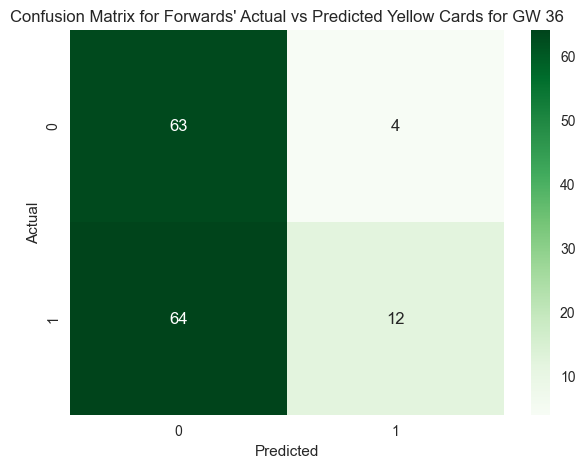

In [146]:
# data_36_fwd_y.reset_index(drop=True, inplace=True)
fwd_y = data_36_fwd_y[['yellow_cards']].copy()
data_36_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

fwd_y_preds_36 = predict_model(fwd_y_model, data=data_36_fwd_y)
fwd_y_preds_36 = fwd_y_preds_36.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_36_fwd
data_36_fwd['yc_preds'] = fwd_y_preds_36['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(fwd_y_preds_36['yc_preds'], fwd_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Forwards' Actual vs Predicted Yellow Cards for GW 36")
plt.show()

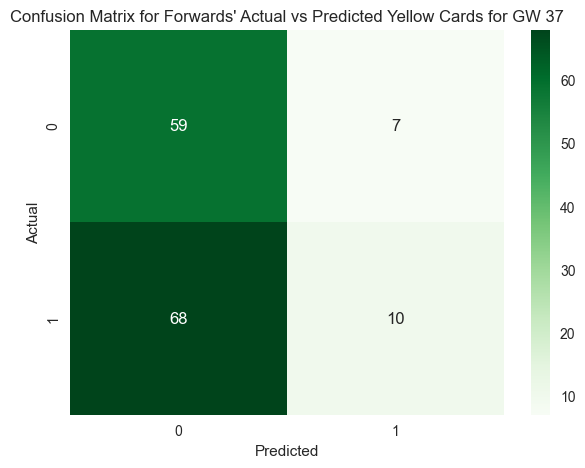

In [147]:
# data_37_fwd_y.reset_index(drop=True, inplace=True)
fwd_y = data_37_fwd_y[['yellow_cards']].copy()
data_37_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

fwd_y_preds_37 = predict_model(fwd_y_model, data=data_37_fwd_y)
fwd_y_preds_37 = fwd_y_preds_37.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_37_fwd
data_37_fwd['yc_preds'] = fwd_y_preds_37['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(fwd_y_preds_37['yc_preds'], fwd_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Forwards' Actual vs Predicted Yellow Cards for GW 37")
plt.show()

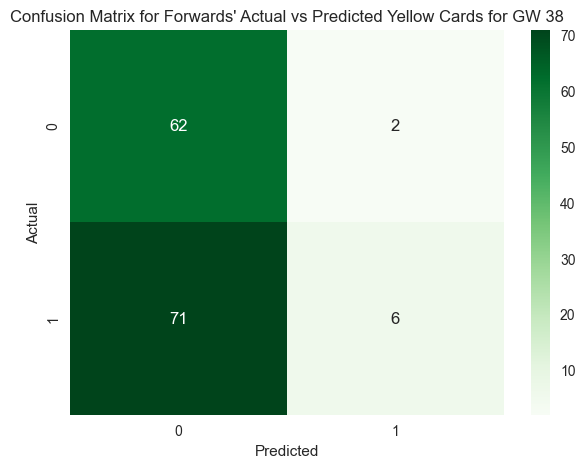

In [148]:
# data_38_fwd_y.reset_index(drop=True, inplace=True)
fwd_y = data_38_fwd_y[['yellow_cards']].copy()
data_38_fwd_y.drop(columns=['position', 'yellow_cards'], inplace=True)

fwd_y_preds_38 = predict_model(fwd_y_model, data=data_38_fwd_y)
fwd_y_preds_38 = fwd_y_preds_38.rename(columns={'prediction_label': 'yc_preds'})

# Add predicted to data_38_fwd
data_38_fwd['yc_preds'] = fwd_y_preds_38['yc_preds']

# Generate a confusion matrix
cm = confusion_matrix(fwd_y_preds_38['yc_preds'], fwd_y['yellow_cards'])
# Plot
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title("Confusion Matrix for Forwards' Actual vs Predicted Yellow Cards for GW 38")
plt.show()

# Combine GW data preds


In [169]:
data_36_gk

,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha,cs_preds,yc_preds
45,0,3,31,1,0.0,14,0.00,0.00,0.0,1.82,...,0.12,2.40,-4915.0,-0.457838,7.0,0.086,0.126,0.788,0,0
463,0,0,9,0,0.0,310,0.00,0.00,0.0,2.31,...,0.30,2.62,-18038.0,-0.597525,2.0,0.474,0.263,0.263,1,1
490,0,1,30,1,0.0,513,0.00,0.00,0.0,2.28,...,0.21,1.40,-3310.0,-0.063593,7.0,0.499,0.264,0.237,1,1
979,0,1,28,1,0.0,146,0.00,0.00,0.0,0.91,...,0.14,0.64,-6751.0,-0.456744,7.0,0.351,0.271,0.379,1,1
1141,0,0,3,0,0.0,248,0.00,0.00,0.0,1.12,...,0.16,1.62,3105.0,-0.037582,2.0,0.516,0.276,0.209,1,1
2457,0,0,7,0,0.0,15,0.00,0.00,0.0,2.56,...,0.21,4.54,-134753.0,-0.871236,2.0,0.474,0.263,0.263,1,1
2495,0,0,23,1,0.0,201,0.00,0.00,0.0,0.68,...,0.09,2.34,-29255.0,-0.570065,6.0,0.359,0.263,0.378,1,1
2913,0,0,19,1,0.0,347,0.00,0.00,0.0,0.10,...,0.21,3.50,77126.0,0.868847,6.0,0.086,0.126,0.788,1,1
3076,0,2,28,1,0.0,47,0.01,0.01,0.0,0.80,...,0.24,3.88,13072.0,0.263253,6.0,0.394,0.263,0.344,1,1
4504,0,0,5,0,0.0,304,0.00,0.00,0.0,1.31,...,0.18,1.08,2184.0,0.243365,1.0,0.704,0.178,0.117,1,1


In [177]:
# Fetch the pred data from reg model
data_36 = pd.read_csv('./models/preds/data_36_with_preds.csv')
data_37 = pd.read_csv('./models/preds/data_37_with_preds.csv')
data_38 = pd.read_csv('./models/preds/data_38_with_preds.csv')
cols_to_add = ['cs_preds', 'yc_preds']

# Merge all the preds and sort by index
preds_36 = pd.concat([data_36_gk, data_36_def, data_36_mid, data_36_fwd]).sort_index()


# Now add the columns to the gw_data
data_36[cols_to_add] = preds_36[cols_to_add]
# data_36.to_csv('./models/preds/data_36_with_preds.csv')
data_36_mid

# # Merge all the preds and sort by index
# preds_37 = pd.concat([data_37_gk, data_37_def, data_37_mid, data_37_fwd]).sort_index()


# # Now add the columns to the gw_data
# data_37[cols_to_add] = preds_37[cols_to_add]
# data_37.to_csv('./models/preds/data_37_with_preds.csv')

# # Merge all the preds and sort by index
# preds_38 = pd.concat([data_38_gk, data_38_def, data_38_mid, data_38_fwd]).sort_index()


# # Now add the columns to the gw_data
# data_38[cols_to_add] = preds_38[cols_to_add]
# # data_38.to_csv('./models/preds/data_38_with_preds.csv')
# data_38[data_38['position'] == 'GK']



,assists_x,bonus,bps,clean_sheets,creativity,element,expected_assists,expected_goal_involvements,expected_goals,expected_goals_conceded,...,xGChain_5,xGBuildup_5,xP_5,ownership_change,percenatge_net_transfers,pts_bps,whh,whd,wha,yc_preds
114,1,0,18,0,11.8,217,0.02,0.02,0.00,0.64,...,0.42,0.16,1.20,14874.0,-0.682823,5.0,0.516,0.276,0.209,1
254,0,0,5,0,14.7,239,0.03,0.03,0.00,0.30,...,0.18,0.09,0.66,32.0,-0.011955,1.0,0.516,0.276,0.209,0
291,0,0,2,0,29.8,372,0.03,0.15,0.12,0.29,...,0.65,0.43,2.40,22921.0,0.721487,1.0,0.499,0.264,0.237,0
328,0,0,19,0,48.3,247,0.19,0.28,0.09,1.12,...,0.31,0.10,2.98,-26291.0,-0.290747,2.0,0.516,0.276,0.209,1
354,0,0,1,0,17.5,77,0.11,0.14,0.03,0.92,...,0.21,0.05,0.76,44.0,0.272727,0.0,0.394,0.263,0.344,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10862,0,0,8,1,26.8,135,0.04,0.06,0.02,0.83,...,0.48,0.19,1.50,3787.0,0.192373,3.0,0.351,0.271,0.379,1
10896,0,0,11,1,2.6,600,0.01,0.04,0.03,0.91,...,0.12,0.07,1.02,67.0,0.183280,3.0,0.351,0.271,0.379,1
10927,0,0,9,1,2.3,111,0.02,0.02,0.00,0.93,...,0.27,0.24,0.96,3648.0,0.226359,2.0,0.189,0.237,0.574,1
11019,0,0,3,0,0.1,97,0.00,0.00,0.00,0.17,...,0.06,0.06,0.08,-17.0,0.008547,1.0,0.189,0.237,0.574,0
